In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter

from scipy.stats import linregress

In [2]:
pplt.rc.axesfacecolor = 'white'

In [3]:
pplt.rc['figure.facecolor'] = 'white'


In [4]:
normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True,
                 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False,
                    'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
ds = xr.open_dataset('/bettik/beaumetj/MARout/MAR-ERA-20C/MARgrid_EUf.nc')
lon = ds.LON[jmin:jmax,imin:imax]
lat = ds.LAT[jmin:jmax,imin:imax]
H = np.array(ds.SH[jmin:jmax,imin:imax])

seasons = ['DJF','MAM','JJA', 'SON']

In [5]:
wp_meanseason_meanT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanT.npy')[:,:,jmin:jmax,imin:imax]
origin_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
slope_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
pvalue_T=np.full(wp_meanseason_meanT.shape[1:4],np.nan)
for i in range(wp_meanseason_meanT.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanT.shape[2]):
        for season in range(4):
            linregress_T = linregress(np.arange(wp_meanseason_meanT.shape[0]), wp_meanseason_meanT[:,season,j,i])
            origin_T[season][j][i] = linregress_T.intercept
            slope_T[season][j][i] = linregress_T.slope
            pvalue_T[season][j][i] = linregress_T.pvalue

In [6]:
origin_T.shape

(4, 91, 139)

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAx

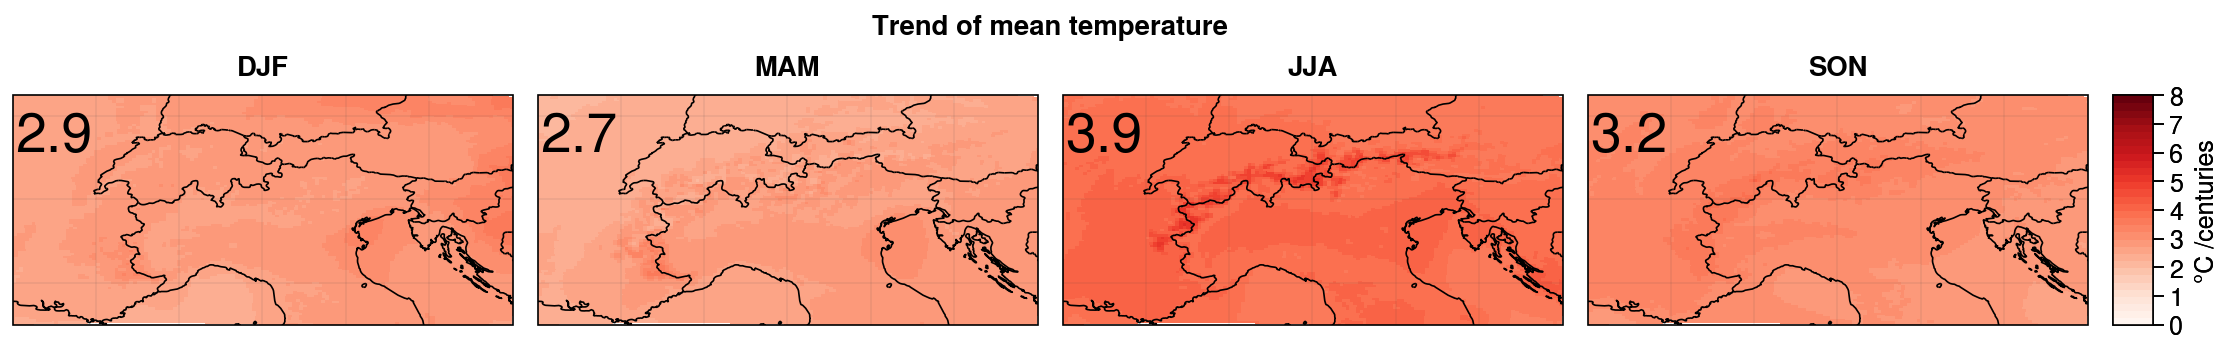

In [7]:
f, axs = pplt.subplots(proj='cyl',ncols=4)

for i in range(4):
    ax = axs[i]
    cb = ax.pcolormesh(lon,lat,100*slope_T[i],levels=np.linspace(0,8,33),cmap='Reds')#'seismic')

    ax.text(5,47.5,"{:.1f}".format(np.mean(100*slope_T[i])),ha='center',va='center',fontsize=20)

f.colorbar(cb, label= '°C /centuries',ticks=np.linspace(0,8,9))

axs.format(**multiplot_format,suptitle='Trend of mean temperature',collabels=['DJF','MAM','JJA', 'SON'])


#### Alps masks

In [8]:
def detect_alps(H):
    nlat,nlon = np.shape(H)
    mask = np.bool_(np.zeros((nlat,nlon)))
    r = 4
    for j in range(r,nlat-r):
        for i in range(r,nlon-r):
            mask[j,i] = np.logical_and(H[j,i]>360 ,np.any(H[j-r:j+r,i-r:i+r]>1300))
            # mask[j,i] = np.std(H[j-r:j+r,i-r:i+r])>200
    return mask
alps = detect_alps(H)
alps[lon<4.8] = False
alps[np.logical_and(lon>10,lat<45.2)] = False


In [9]:
ne_alps = np.copy(alps) # ne : north-east
ne_alps[lat<46.7] = False


nw_alps2 = np.copy(alps) # nw : north-west
nw_alps2[lon>7.9] = False
nw_alps2[lat<45.9] = False
nw_alps2[lat>46.7] = False

nw_alps3 = np.copy(alps) # nw : north-west
nw_alps3[lon>6.9] = False
nw_alps3[lat<44.8] = False
nw_alps3[lat>46.7] = False

nw_alps4 = np.copy(alps) # nw : north-west
nw_alps4[lon>8.3] = False
nw_alps4[lat<46.4] = False
nw_alps4[lat>46.7] = False

nw_alps5 = np.copy(alps) # nw : north-west
nw_alps5[lon>7.1] = False
nw_alps5[lat<45.2] = False
nw_alps5[lat>46.7] = False

nw_alps = np.logical_or(np.logical_or(np.logical_or(nw_alps2,nw_alps3),nw_alps4),nw_alps5)


s_alps = np.logical_and(alps,np.invert(np.logical_or(nw_alps,ne_alps)))

#### Scatter plots for temperature trends as a function of altitude

In [10]:
def get_slopes(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:54,:,:,:]
    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
                origin_fut[season][j][i] = linregress_fut.intercept
                slope_fut[season][j][i] = linregress_fut.slope
                pvalue_fut[season][j][i] = linregress_fut.pvalue

    return slope_hist, slope_fut

In [11]:
def get_slopes_and_pvalue(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:54,:,:,:]
    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
                origin_fut[season][j][i] = linregress_fut.intercept
                slope_fut[season][j][i] = linregress_fut.slope
                pvalue_fut[season][j][i] = linregress_fut.pvalue

    return slope_hist, slope_fut, pvalue_hist, pvalue_fut

In [12]:
def plot_4reg_4seas(Slope_hist,Slope_fut,Xlim,Suptitle,Xlabel):
    f, axs = pplt.subplots(ncols=4, nrows=4)
    leg = ['1961-2014','2015-2100']
    
    for i in range(4):
        slope_hist_alps = np.ma.masked_array(Slope_hist[i], mask=np.invert(alps))
        slope_hist_ne_alps = np.ma.masked_array(Slope_hist[i], mask=np.invert(ne_alps))
        slope_hist_nw_alps = np.ma.masked_array(Slope_hist[i], mask=np.invert(nw_alps))
        slope_hist_s_alps = np.ma.masked_array(Slope_hist[i], mask=np.invert(s_alps))
        slopes=[slope_hist_alps,slope_hist_ne_alps,slope_hist_nw_alps,slope_hist_s_alps]
        
        for j,slope in enumerate(slopes):
            ax = axs[i+4*j]
            hist_dots = ax.scatter(10*slope.flatten(),H.flatten(),s=2,label=leg[0])
        
    
    for i in range(4):
        slope_fut_alps = np.ma.masked_array(Slope_fut[i], mask=np.invert(alps))
        slope_fut_ne_alps = np.ma.masked_array(Slope_fut[i], mask=np.invert(ne_alps))
        slope_fut_nw_alps = np.ma.masked_array(Slope_fut[i], mask=np.invert(nw_alps))
        slope_fut_s_alps = np.ma.masked_array(Slope_fut[i], mask=np.invert(s_alps))
        slopes=[slope_fut_alps,slope_fut_ne_alps,slope_fut_nw_alps,slope_fut_s_alps]
        
        for j,slope in enumerate(slopes):
            ax = axs[i+4*j]
            fut_dots = ax.scatter(10*slope.flatten(),H.flatten(),s=2,label=leg[1])
            ax.set_xlim(Xlim)
            ax.set_ylim((0.,3500))
            #if(j==3):
            #    ax.legend([blue_dot,orange_dot],leg,loc='bottom')
    
    axs.format(suptitle=Suptitle,collabels=['DJF','MAM','JJA', 'SON'],
           rowlabels=['Alps','NE Alps','NW Alps','Southern Alps'],xlabel=Xlabel,ylabel='Elevation (m.a.s.l.)')
    f.legend([hist_dots,fut_dots],loc='bottom')

In [13]:
slope_T_hist,slope_T_fut = get_slopes(wp_meanseason_meanT)

(0.0, 3500.0)

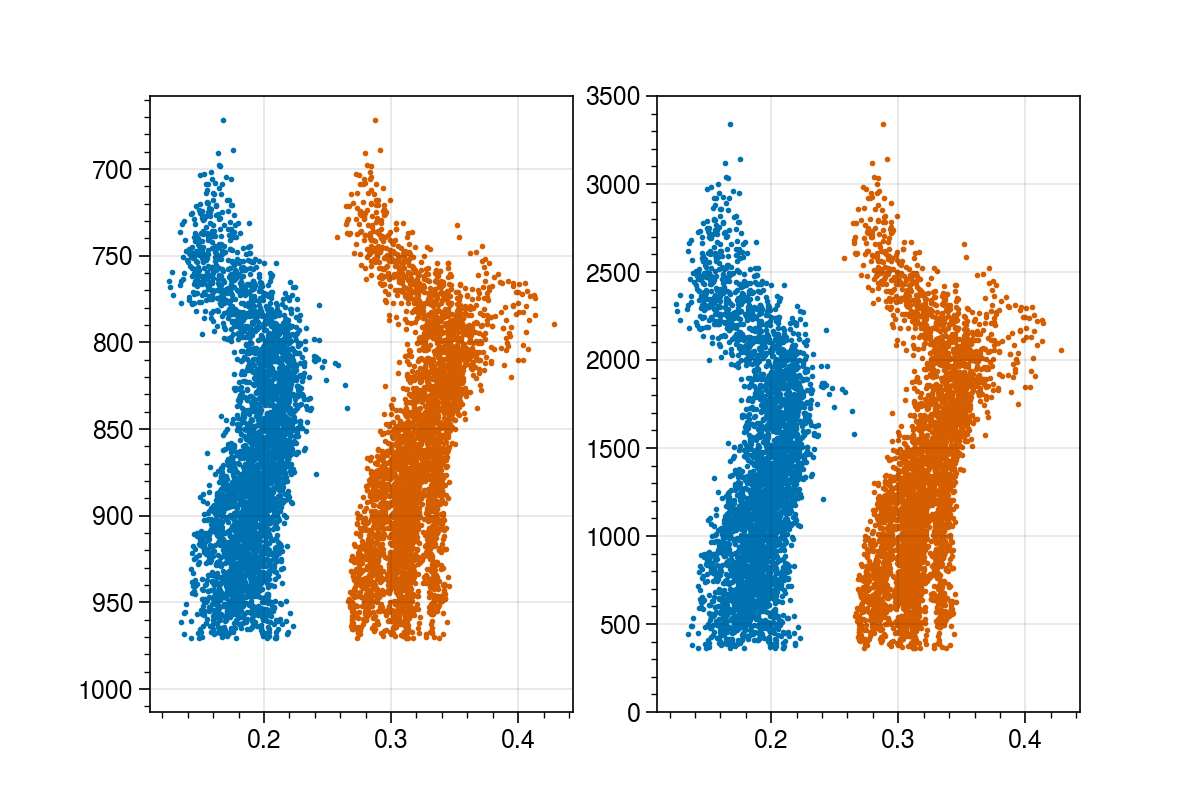

In [14]:
# Ajout de coordonnée verticale pression dans le cas de l'atmosphère standard OACI
def z_to_p(H):
    p0 = 1013.25 # hPa
    gamma = 6.5*10**(-3) # K/m
    T0 = 288.5 # K
    g = 9.81 # m.s^-2
    R = 287 # J/kg/K
    pressure = p0*(1-gamma/T0*H)**(g/gamma/R)
    return pressure

# compare with pressure coordinate

f, axs = plt.subplots(ncols=2,figsize=(6, 4))
leg = ['1961-2014','2015-2100']

ax = axs[0]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),z_to_p(ds.SH[jmin:jmax,imin:imax]),s=2)
ax.set_ylim((1013.25,657.85))

ax = axs[1]
blue_dot = ax.scatter(10*np.ma.masked_array(slope_T_hist[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
orange_dot = ax.scatter(10*np.ma.masked_array(slope_T_fut[1], mask=np.invert(alps)),ds.SH[jmin:jmax,imin:imax],s=2)
ax.set_ylim((0,3500))

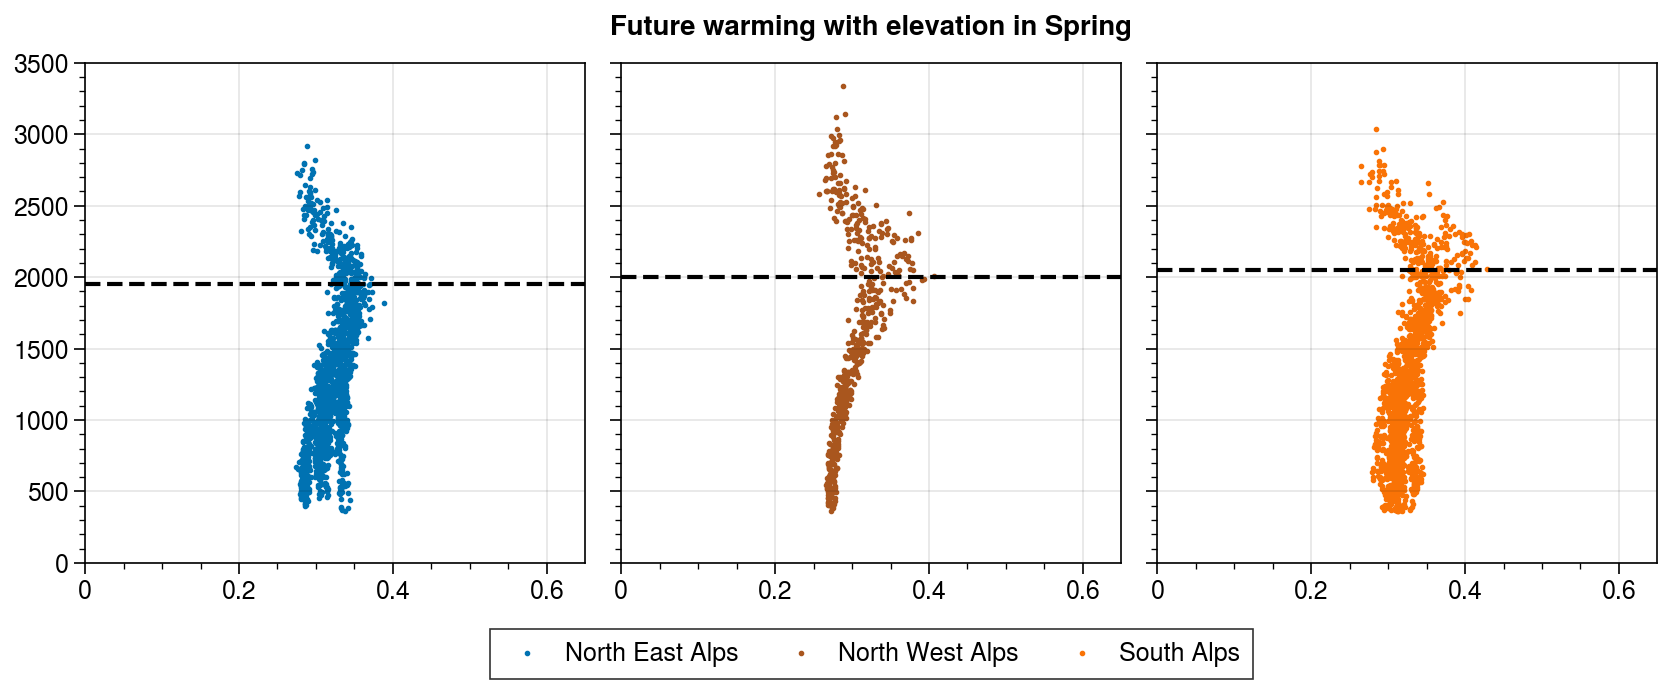

In [15]:
f,axs = pplt.subplots(ncols=3)
i=1

slope_T_fut_ne_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(ne_alps))
slope_T_fut_nw_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(nw_alps))
slope_T_fut_s_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(s_alps))

axs[0].scatter(10*slope_T_fut_ne_alps.flatten(),H.flatten(),s=2,label='North East Alps')
axs[0].plot([0,0.7],[1950,1950],color='k',linestyle='--')
axs[1].scatter(10*slope_T_fut_nw_alps.flatten(),H.flatten(),s=2,label='North West Alps',color='sienna')
axs[1].plot([0,0.7],[2000,2000],color='k',linestyle='--')
axs[2].scatter(10*slope_T_fut_s_alps.flatten(),H.flatten(),s=2,label='South Alps',color='orange')
axs[2].plot([0,0.7],[2050,2050],color='k',linestyle='--')
#axs.set_xlim((0.,0.65))
#axs.set_ylim((0.,3500))
f.legend(loc='b')
axs.format(suptitle='Future warming with elevation in Spring',xlim=(0.,0.65),ylim=(0.,3500))

/tmp/ipykernel_411371/3926002182.py:1: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=12, large=12)
/tmp/ipykernel_411371/3926002182.py:1: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=12, large=12)


Text(0.5, 1.0, 'Warming in Spring in the Alps')

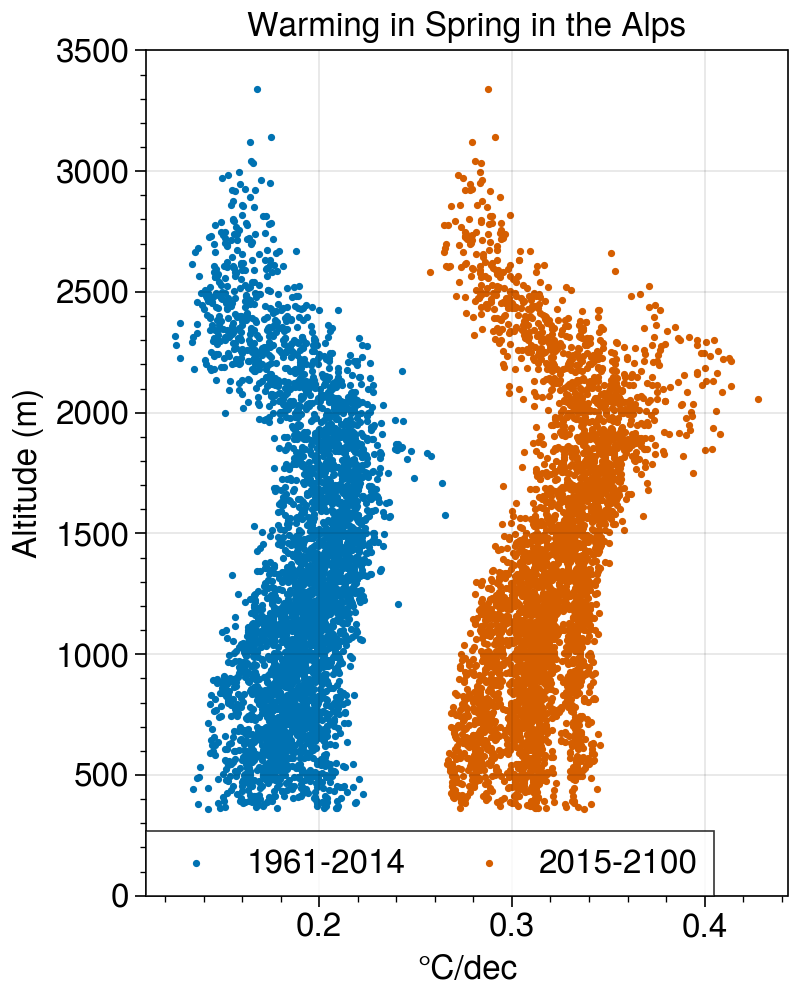

In [16]:
pplt.rc.update(small=12, large=12)

f,ax = pplt.subplots(figsize=(4,5))
leg = ['1961-2014','2015-2100']

#plt.figure().set_figwidth(4)
ax.scatter(10*np.ma.masked_array(slope_T_hist[1].flatten(), mask=np.invert(alps)),H.flatten(),s=4,label=leg[0])
ax.scatter(10*np.ma.masked_array(slope_T_fut[1].flatten(), mask=np.invert(alps)),H.flatten(),s=4,label=leg[1])
ax.set_ylim((0,3500))
ax.legend()
ax.set_xlabel('°C/dec')
ax.set_ylabel('Altitude (m)')
ax.set_title('Warming in Spring in the Alps')


### Net Shortwave radiation trend

In [17]:
# SWD : Short Wave Down, SWU : Short Wave Up, NWS : Net Short Wave

wp_meanseason_meanSWD = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanSWD.npy')[:,:,jmin:jmax,imin:imax]
wp_meanseason_meanSWU = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanSWU.npy')[:,:,jmin:jmax,imin:imax]

wp_meanseason_meanNSW = wp_meanseason_meanSWD - wp_meanseason_meanSWU

wp_meanseason_meanNSW_hist = wp_meanseason_meanNSW[:54,:,:,:]
wp_meanseason_meanNSW_fut = wp_meanseason_meanNSW[55:,:,:,:]

origin_NSW_hist=np.full(wp_meanseason_meanNSW_hist.shape[1:4],np.nan)
slope_NSW_hist=np.full(wp_meanseason_meanNSW_hist.shape[1:4],np.nan)
pvalue_NSW_hist=np.full(wp_meanseason_meanNSW_hist.shape[1:4],np.nan)

origin_NSW_fut=np.full(wp_meanseason_meanNSW_fut.shape[1:4],np.nan)
slope_NSW_fut=np.full(wp_meanseason_meanNSW_fut.shape[1:4],np.nan)
pvalue_NSW_fut=np.full(wp_meanseason_meanNSW_fut.shape[1:4],np.nan)

for i in range(wp_meanseason_meanNSW_fut.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanNSW_fut.shape[2]):
        for season in range(4):
            linregress_NSW_hist = linregress(np.arange(wp_meanseason_meanNSW_hist.shape[0]), wp_meanseason_meanNSW_hist[:,season,j,i])
            origin_NSW_hist[season][j][i] = linregress_NSW_hist.intercept
            slope_NSW_hist[season][j][i] = linregress_NSW_hist.slope
            pvalue_NSW_hist[season][j][i] = linregress_NSW_hist.pvalue
            
            linregress_NSW_fut = linregress(np.arange(wp_meanseason_meanNSW_fut.shape[0]), wp_meanseason_meanNSW_fut[:,season,j,i])
            origin_NSW_fut[season][j][i] = linregress_NSW_fut.intercept
            slope_NSW_fut[season][j][i] = linregress_NSW_fut.slope
            pvalue_NSW_fut[season][j][i] = linregress_NSW_fut.pvalue

### Specific Humidity

In [18]:
# QQz at 2m

wp_meanseason_meanQQz = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meanQQz.npy')[:,:,jmin:jmax,imin:imax]

wp_meanseason_meanQQz_hist = wp_meanseason_meanQQz[:54,:,:,:]
wp_meanseason_meanQQz_fut = wp_meanseason_meanQQz[55:,:,:,:]

origin_QQz_hist=np.full(wp_meanseason_meanQQz_hist.shape[1:4],np.nan)
slope_QQz_hist=np.full(wp_meanseason_meanQQz_hist.shape[1:4],np.nan)
pvalue_QQz_hist=np.full(wp_meanseason_meanQQz_hist.shape[1:4],np.nan)

origin_QQz_fut=np.full(wp_meanseason_meanQQz_fut.shape[1:4],np.nan)
slope_QQz_fut=np.full(wp_meanseason_meanQQz_fut.shape[1:4],np.nan)
pvalue_QQz_fut=np.full(wp_meanseason_meanQQz_fut.shape[1:4],np.nan)

for i in range(wp_meanseason_meanQQz_fut.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanQQz_fut.shape[2]):
        for season in range(4):
            linregress_QQz_hist = linregress(np.arange(wp_meanseason_meanQQz_hist.shape[0]), wp_meanseason_meanQQz_hist[:,season,j,i])
            origin_QQz_hist[season][j][i] = linregress_QQz_hist.intercept
            slope_QQz_hist[season][j][i] = linregress_QQz_hist.slope
            pvalue_QQz_hist[season][j][i] = linregress_QQz_hist.pvalue
            
            linregress_QQz_fut = linregress(np.arange(wp_meanseason_meanQQz_fut.shape[0]), wp_meanseason_meanQQz_fut[:,season,j,i])
            origin_QQz_fut[season][j][i] = linregress_QQz_fut.intercept
            slope_QQz_fut[season][j][i] = linregress_QQz_fut.slope
            pvalue_QQz_fut[season][j][i] = linregress_QQz_fut.pvalue

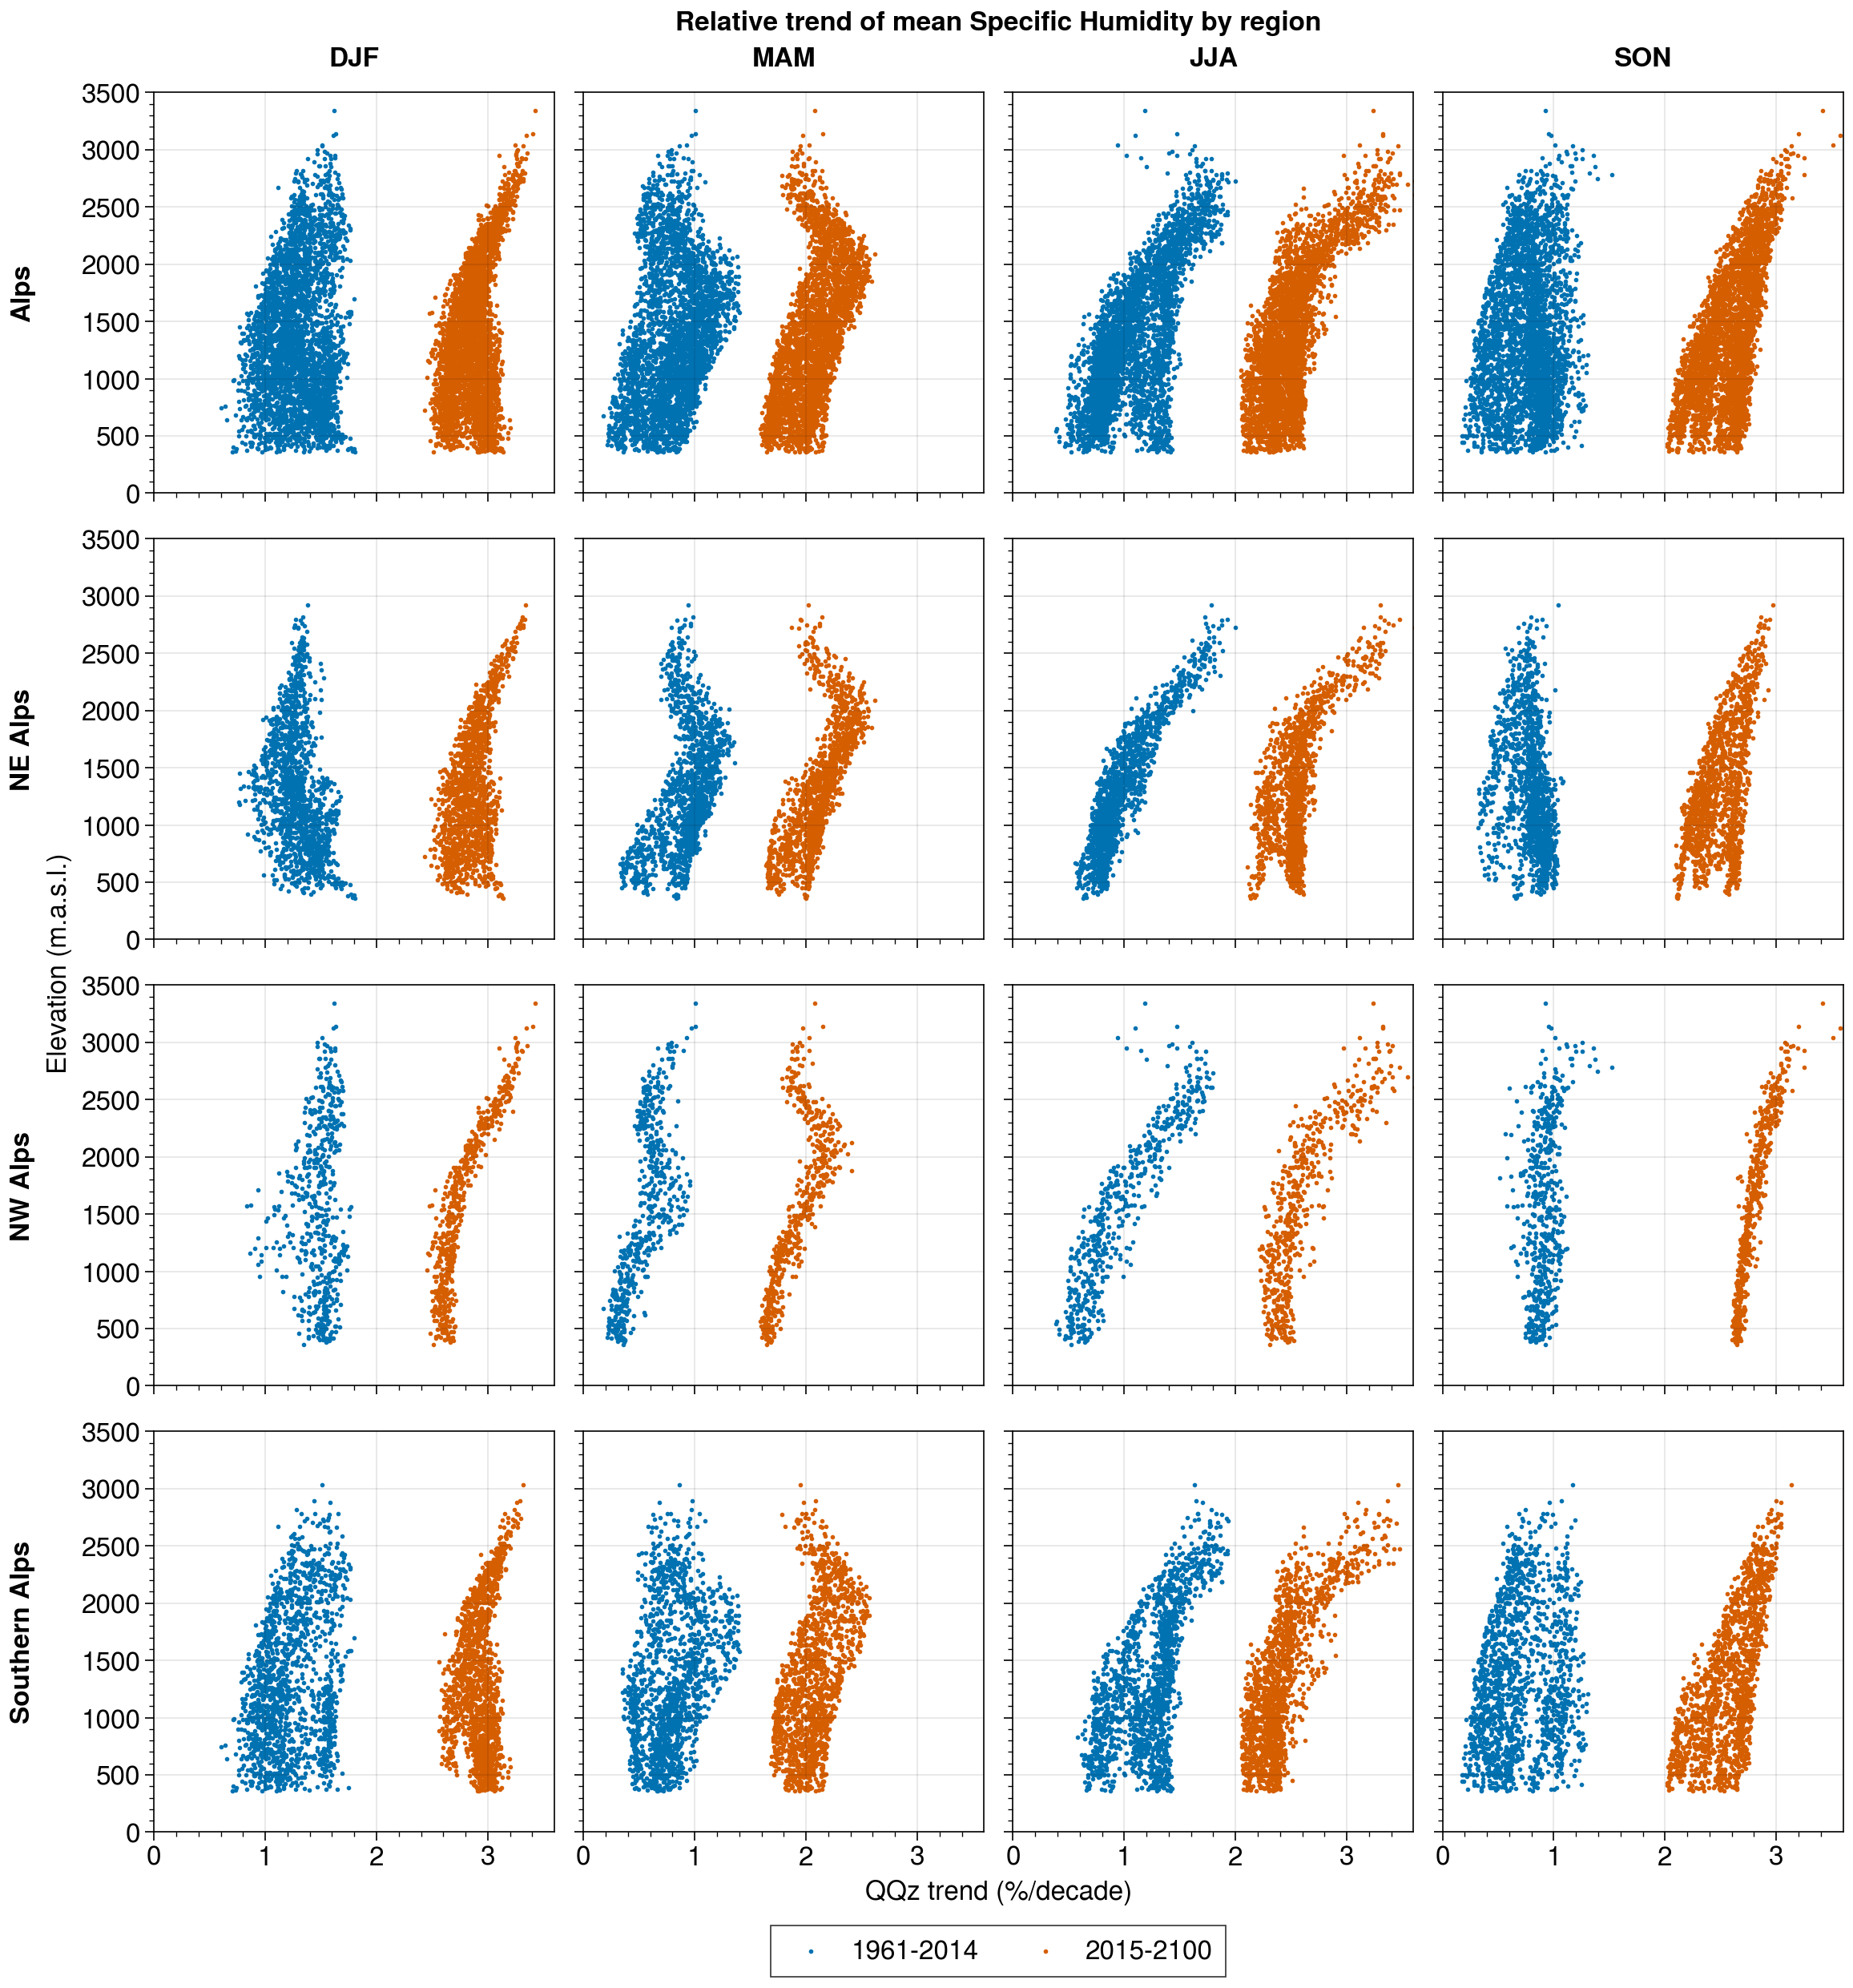

In [19]:
# same plot but normalized by mean of period
meanQQz_hist = wp_meanseason_meanQQz_hist.mean(axis=0)
meanQQz_fut = wp_meanseason_meanQQz_fut.mean(axis=0)

plot_4reg_4seas(100*slope_QQz_hist/meanQQz_hist,100*slope_QQz_fut/meanQQz_fut,Xlim=(0.,3.6),
                Suptitle='Relative trend of mean Specific Humidity by region',Xlabel='QQz trend (%/decade)')

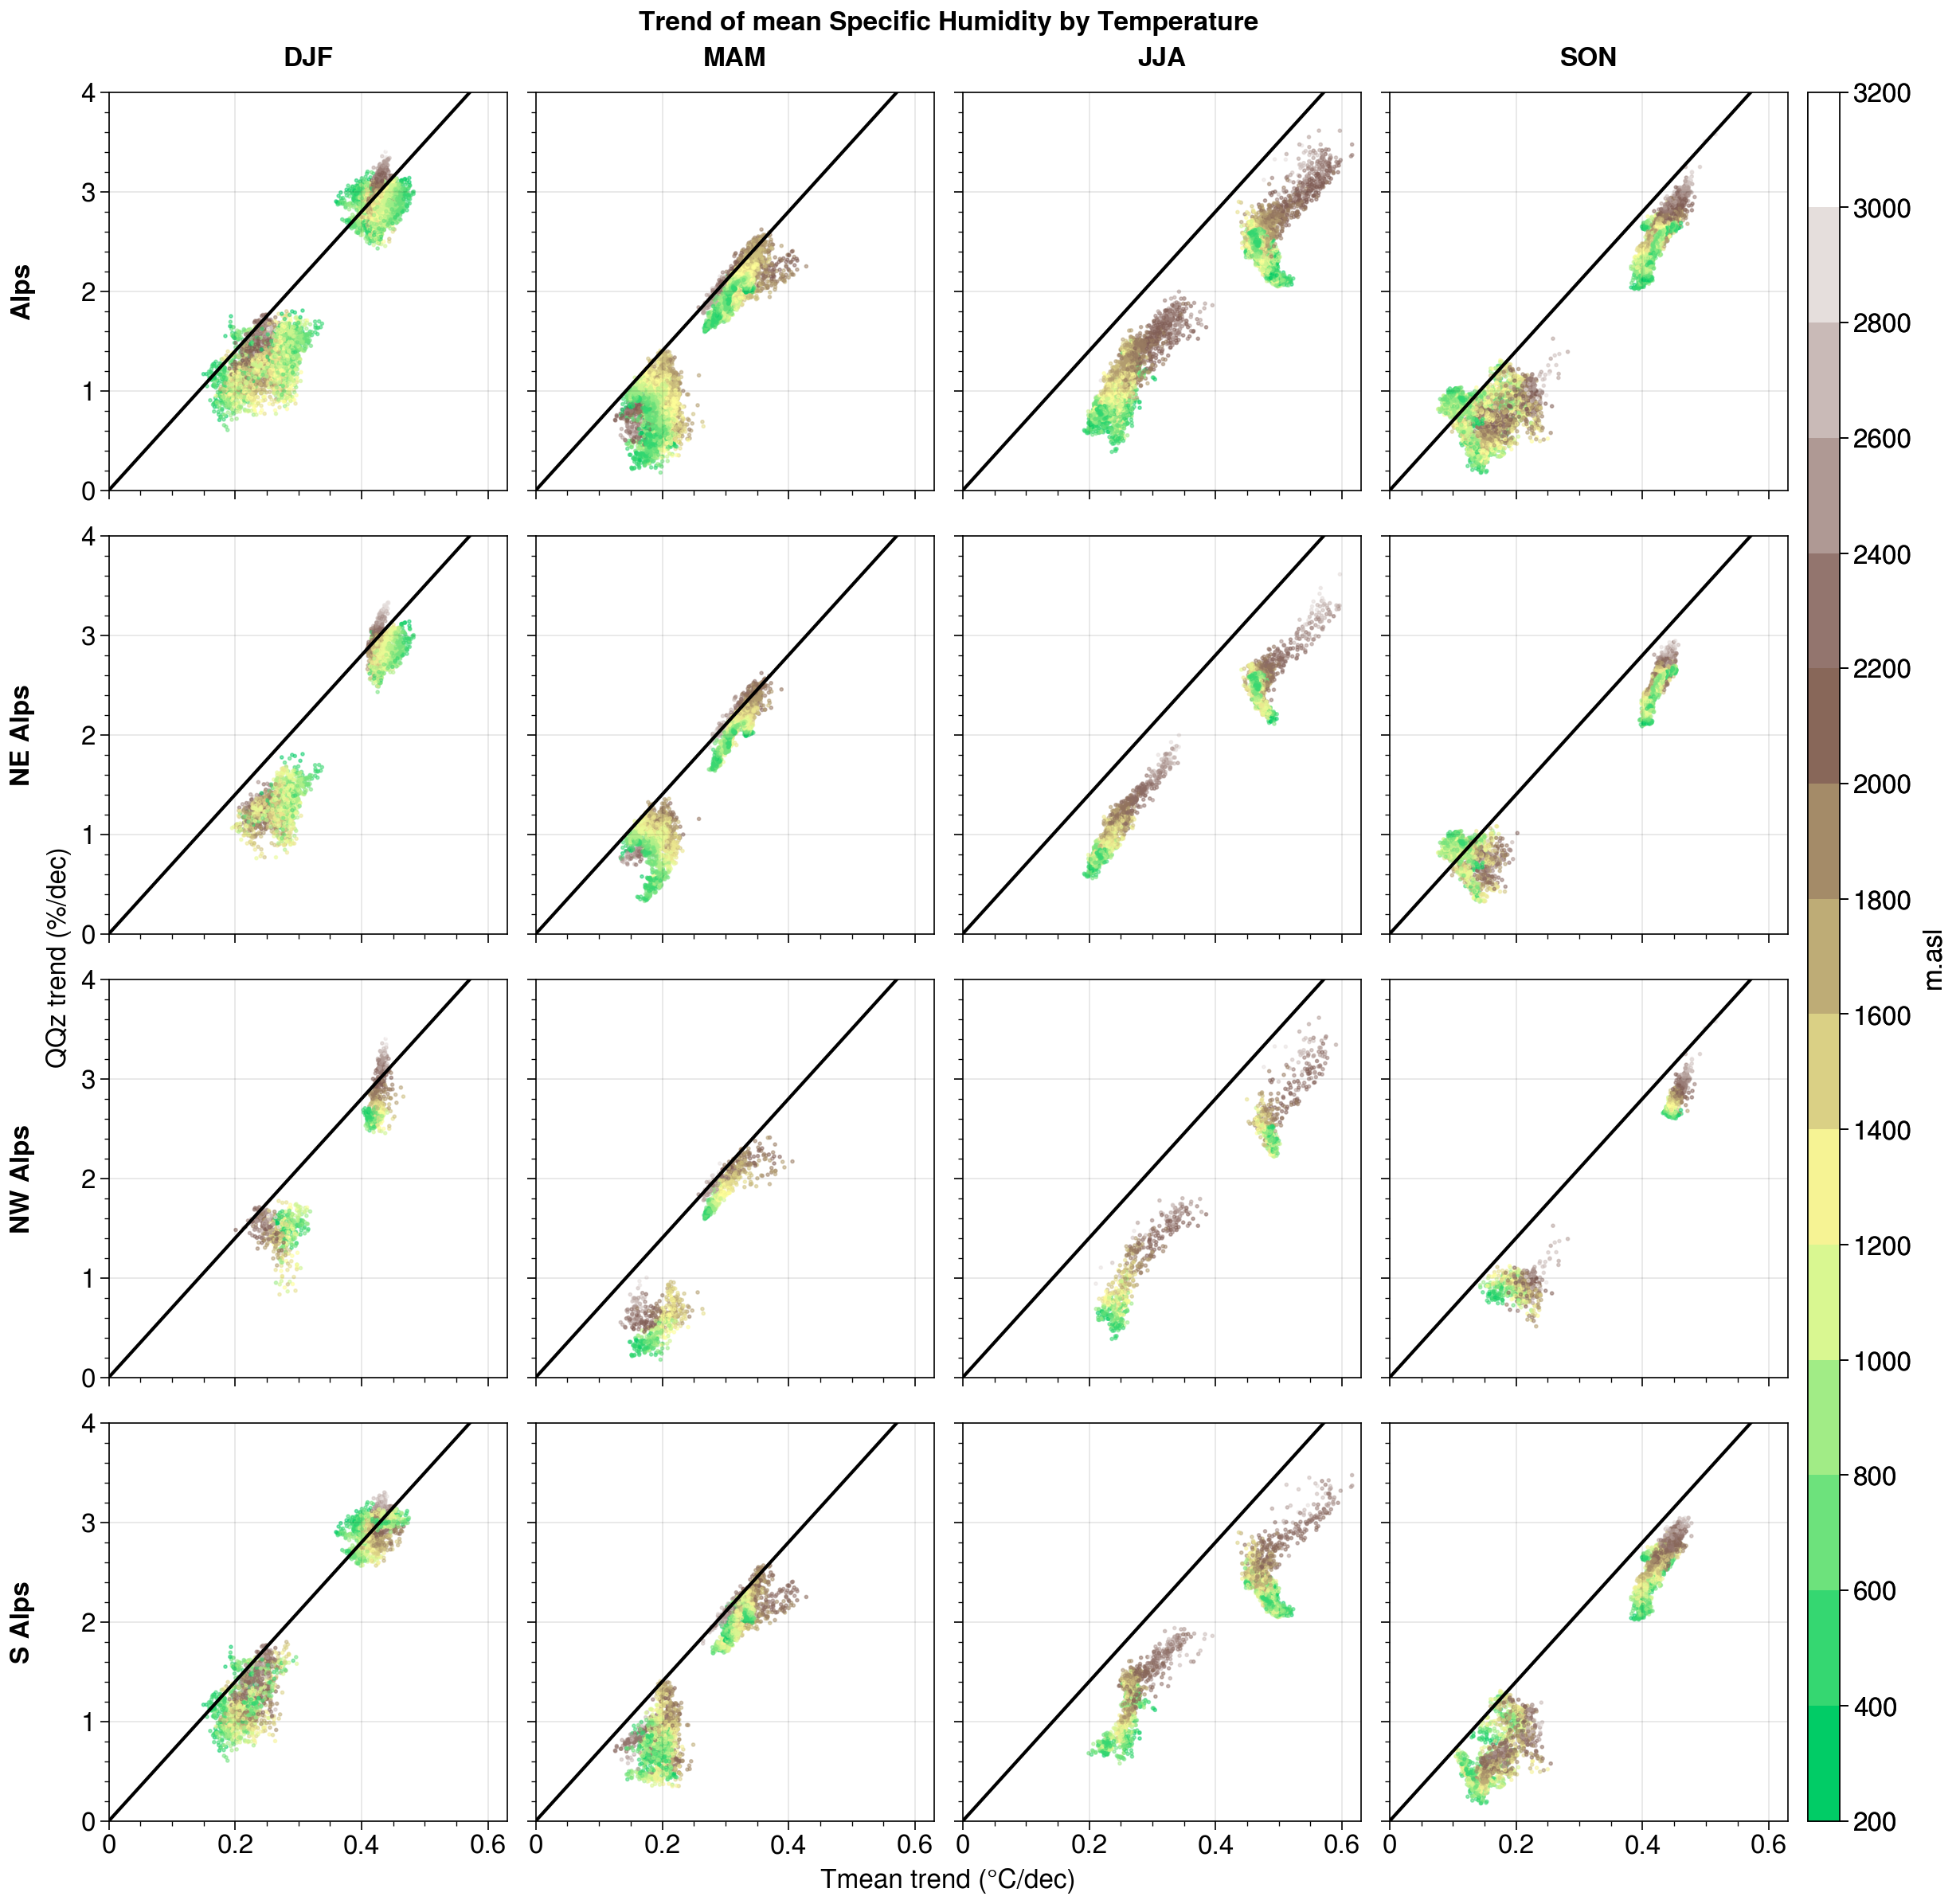

In [20]:
### NEW REGIONS
# humidity normalized by mean of period
# pplt.rc['figure.facecolor'] = 'gray1'
# pplt.rc.axesfacecolor = 'gray6'

f, axs = pplt.subplots(ncols=4, nrows=4)
leg = ['1961-2014','2015-2100']

meanQQz_hist = wp_meanseason_meanQQz_hist.mean(axis=0)
meanQQz_fut = wp_meanseason_meanQQz_fut.mean(axis=0)

H_alps = np.ma.masked_array(H, mask=np.invert(alps))
H_alps_ne = np.ma.masked_array(H, mask=np.invert(ne_alps))
H_alps_nw = np.ma.masked_array(H, mask=np.invert(nw_alps))
H_alps_s = np.ma.masked_array(H, mask=np.invert(s_alps))
Heights = [H_alps.flatten(),H_alps_ne.flatten(),H_alps_nw.flatten(),H_alps_s.flatten()]

for i in range(4):
    slope_QQz_hist_alps = np.ma.masked_array(slope_QQz_hist[i]/meanQQz_hist[i], mask=np.invert(alps))
    slope_QQz_hist_east_alps = np.ma.masked_array(slope_QQz_hist[i]/meanQQz_hist[i], mask=np.invert(ne_alps))
    slope_QQz_hist_north_alps = np.ma.masked_array(slope_QQz_hist[i]/meanQQz_hist[i], mask=np.invert(nw_alps))
    slope_QQz_hist_south_alps = np.ma.masked_array(slope_QQz_hist[i]/meanQQz_hist[i], mask=np.invert(s_alps))
    
    slope_T_hist_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(alps))
    slope_T_hist_east_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(ne_alps))
    slope_T_hist_north_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(nw_alps))
    slope_T_hist_south_alps = np.ma.masked_array(slope_T_hist[i], mask=np.invert(s_alps))
    
    slopes_Q=[slope_QQz_hist_alps.flatten(),slope_QQz_hist_east_alps.flatten(),slope_QQz_hist_north_alps.flatten(),slope_QQz_hist_south_alps.flatten()]
    slopes_T=[slope_T_hist_alps.flatten(),slope_T_hist_east_alps.flatten(),slope_T_hist_north_alps.flatten(),slope_T_hist_south_alps.flatten()]
    
    for j,slope in enumerate(slopes_Q):
        ax = axs[i+4*j]
        past_dot = ax.scatter(10*slopes_T[j],10*slope*100,s=2,alpha=0.5,c=Heights[j],cmap=colors_land,levels=17) # *100 to put in percent
        ax.plot([0,1],[0,7],c='k')
        
    
for i in range(4):
    slope_QQz_fut_alps = np.ma.masked_array(slope_QQz_fut[i]/meanQQz_fut[i], mask=np.invert(alps))
    slope_QQz_fut_east_alps = np.ma.masked_array(slope_QQz_fut[i]/meanQQz_fut[i], mask=np.invert(ne_alps))
    slope_QQz_fut_north_alps = np.ma.masked_array(slope_QQz_fut[i]/meanQQz_fut[i], mask=np.invert(nw_alps))
    slope_QQz_fut_south_alps = np.ma.masked_array(slope_QQz_fut[i]/meanQQz_fut[i], mask=np.invert(s_alps))
    
    slope_T_fut_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(alps))
    slope_T_fut_east_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(ne_alps))
    slope_T_fut_north_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(nw_alps))
    slope_T_fut_south_alps = np.ma.masked_array(slope_T_fut[i], mask=np.invert(s_alps))
    
    slopes_Q=[slope_QQz_fut_alps.flatten(),slope_QQz_fut_east_alps.flatten(),slope_QQz_fut_north_alps.flatten(),slope_QQz_fut_south_alps.flatten()]
    slopes_T=[slope_T_fut_alps.flatten(),slope_T_fut_east_alps.flatten(),slope_T_fut_north_alps.flatten(),slope_T_fut_south_alps.flatten()]
    
    for j,slope in enumerate(slopes_Q):
        ax = axs[i+4*j]
        future_dot = ax.scatter(10*slopes_T[j],10*slope*100,s=2,alpha=0.5,c=Heights[j],cmap=colors_land,levels=17) # *100 to put in percent
        ax.set_xlim((0.,0.63))
        ax.set_ylim((0.,4))
        #if(j==3):
        #    ax.legend([blue_dot,orange_dot],leg,loc='bottom')

cbar = f.colorbar(past_dot,label= 'm.asl')
cbar.solids.set(alpha=1)
axs.format(suptitle='Trend of mean Specific Humidity by Temperature',collabels=['DJF','MAM','JJA', 'SON'],
           rowlabels=['Alps','NE Alps','NW Alps','S Alps'],xlabel='Tmean trend (°C/dec)',ylabel='QQz trend (%/dec)')

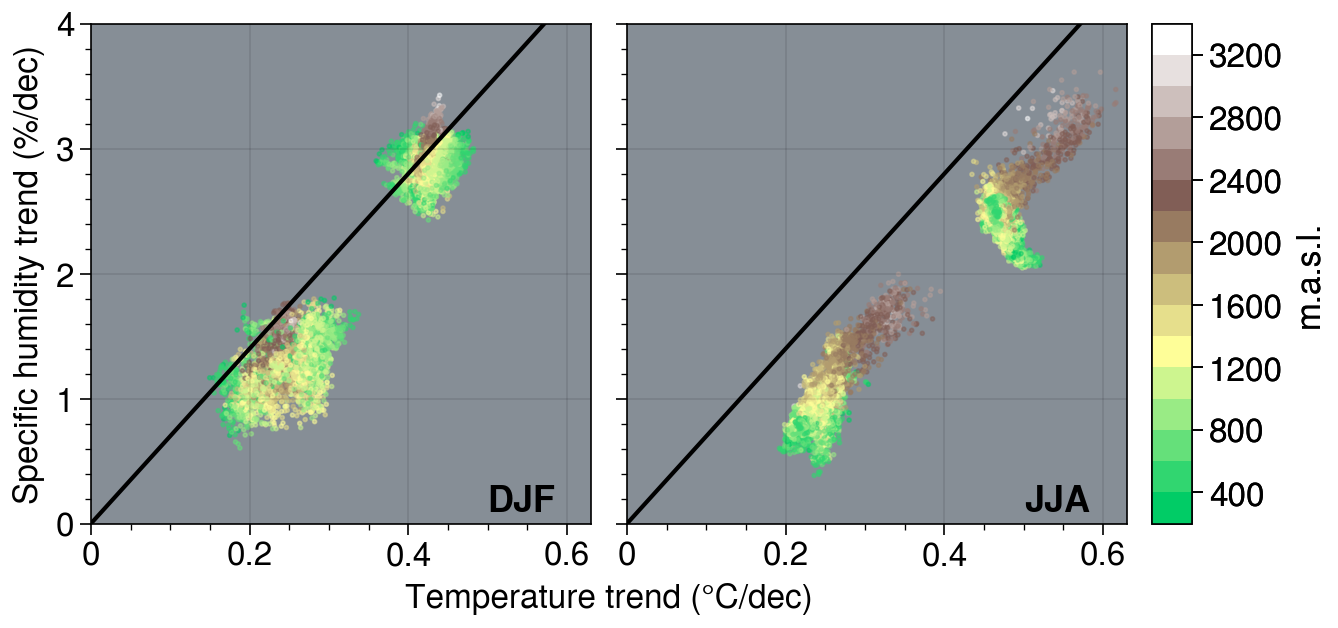

In [26]:
### NEW REGIONS
# humidity normalized by mean of period
# pplt.rc['figure.facecolor'] = 'gray1'
pplt.rc.axesfacecolor = 'gray6'

f, axs = pplt.subplots(ncols=2)
leg = ['1961-2014','2015-2100']

meanQQz_hist = wp_meanseason_meanQQz_hist.mean(axis=0)
meanQQz_fut = wp_meanseason_meanQQz_fut.mean(axis=0)

H_alps = np.ma.masked_array(H, mask=np.invert(alps))
Heights = H_alps.flatten()
seasons=["DJF","MAM","JJA","SON"]

i=0

for seas in [0,2]:
    slope_QQz_hist_alps = np.ma.masked_array(slope_QQz_hist[seas]/meanQQz_hist[seas], mask=np.invert(alps))
    
    slope_T_hist_alps = np.ma.masked_array(slope_T_hist[seas], mask=np.invert(alps))
    
    slope_Q=slope_QQz_hist_alps.flatten()
    slope_T=slope_T_hist_alps.flatten()
    
    ax = axs[i]
    past_dot = ax.scatter(10*slope_T,10*slope_Q*100,s=2,alpha=0.5,c=Heights,cmap=colors_land,levels=17) # *100 to put in percent
    ax.plot([0,1],[0,7],c='k')
    i=i+1
        
i=0

for seas in [0,2]:
    slope_QQz_fut_alps = np.ma.masked_array(slope_QQz_fut[seas]/meanQQz_fut[seas], mask=np.invert(alps))
    
    slope_T_fut_alps = np.ma.masked_array(slope_T_fut[seas], mask=np.invert(alps))
    
    slope_Q=slope_QQz_fut_alps.flatten()
    slope_T=slope_T_fut_alps.flatten()
    
    ax = axs[i]
    future_dot = ax.scatter(10*slope_T,10*slope_Q*100,s=2,alpha=0.5,c=Heights,cmap=colors_land,levels=17) # *100 to put in percent
    ax.set_xlim((0.,0.63))
    ax.set_ylim((0.,4))
    ax.text(0.5, 0.1, seasons[seas], fontsize=13,fontweight='semibold')
    i=i+1


cbar = f.colorbar(past_dot,label= 'm.a.s.l.')
cbar.solids.set(alpha=1)
axs.format(xlabel='Temperature trend (°C/dec)',ylabel='Specific humidity trend (%/dec)')
f.save("/summer/mar/castelli/figs/Manuscript/f2.2.png", dpi=300, bbox_inches='tight')

#### Trend over whole 1961-2100 period

In [21]:
origin_QQz=np.full(wp_meanseason_meanQQz.shape[1:4],np.nan)
slope_QQz=np.full(wp_meanseason_meanQQz.shape[1:4],np.nan)
pvalue_QQz=np.full(wp_meanseason_meanQQz.shape[1:4],np.nan)

for i in range(wp_meanseason_meanQQz.shape[3]):
    # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
    for j in range(wp_meanseason_meanQQz.shape[2]):
        for season in range(4):
            linregress_ = linregress(np.arange(wp_meanseason_meanQQz.shape[0]), wp_meanseason_meanQQz[:,season,j,i])
            origin_QQz[season][j][i] = linregress_.intercept
            slope_QQz[season][j][i] = linregress_.slope
            pvalue_QQz[season][j][i] = linregress_.pvalue


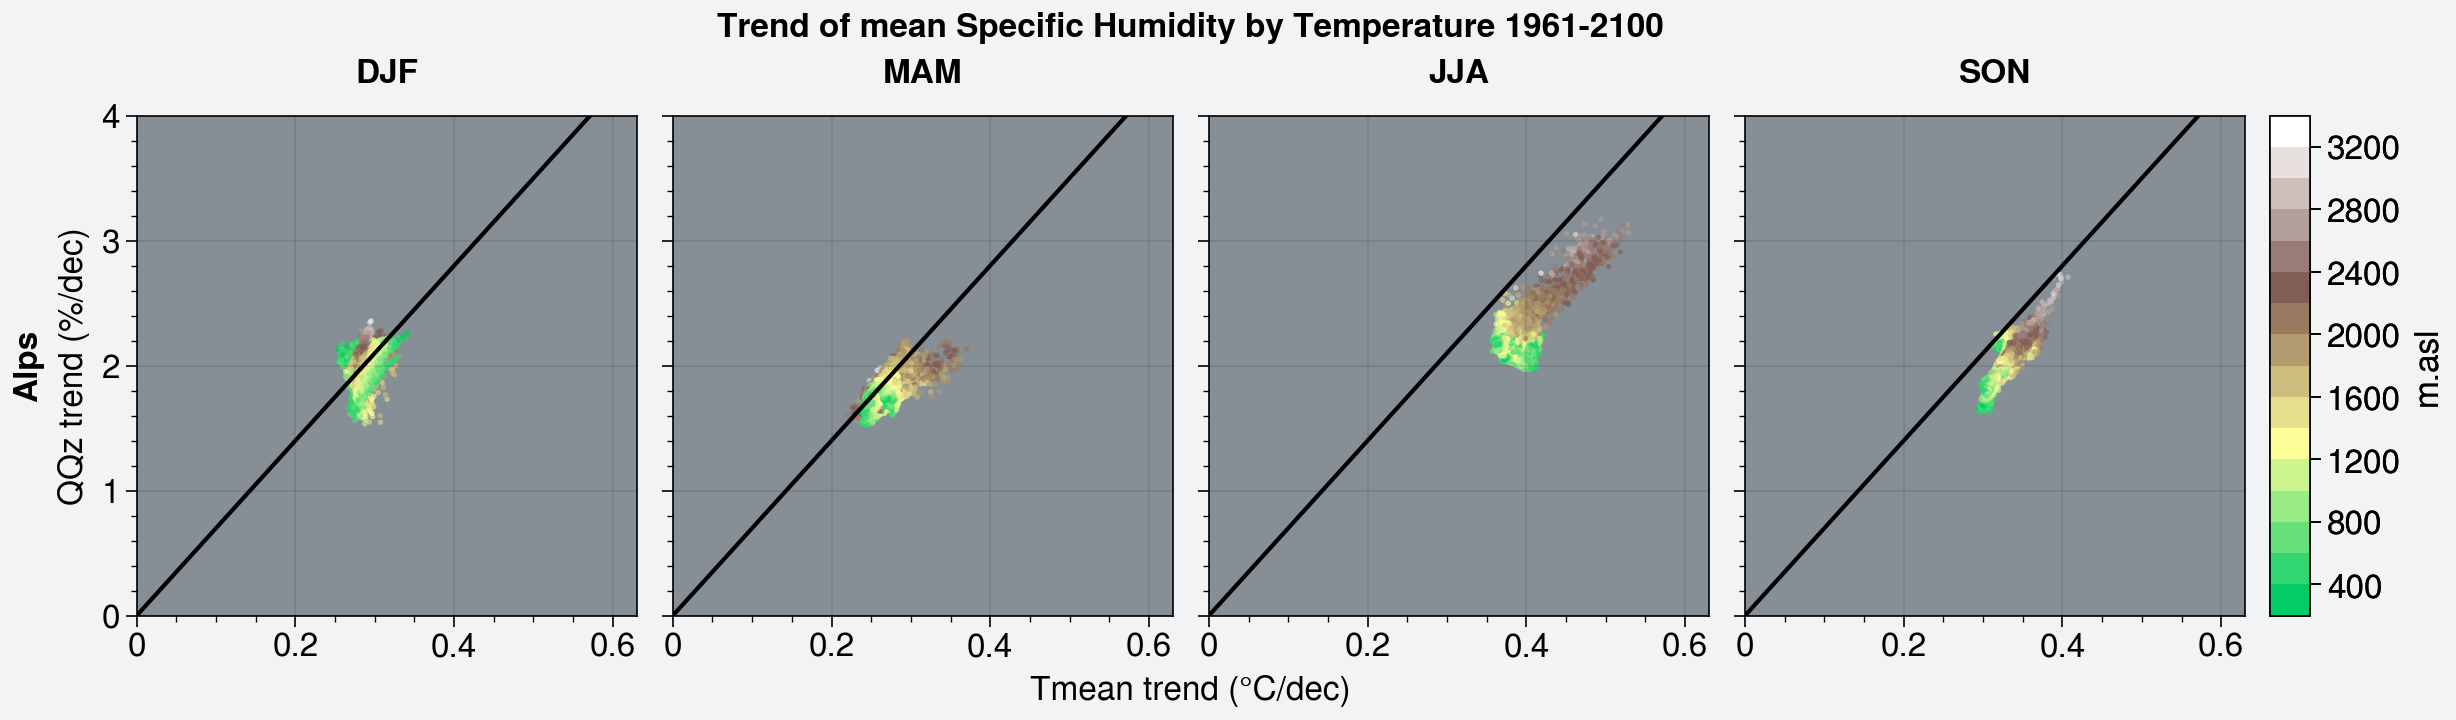

In [22]:
pplt.rc['figure.facecolor'] = 'gray1'
pplt.rc.axesfacecolor = 'gray6'

f, axs = pplt.subplots(ncols=4)

meanQQz = wp_meanseason_meanQQz.mean(axis=0)

H_alps = np.ma.masked_array(H, mask=np.invert(alps)).flatten()

for i in range(4):
    slope_QQz_alps = np.ma.masked_array(slope_QQz[i]/meanQQz[i], mask=np.invert(alps)).flatten()
    
    slope_T_alps = np.ma.masked_array(slope_T[i], mask=np.invert(alps)).flatten()

    ax = axs[i]
    wp_dot = ax.scatter(10*slope_T_alps,10*slope_QQz_alps*100,s=2,alpha=0.5,c=H_alps,cmap=colors_land,levels=17) # *100 to put in percent
    ax.plot([0,1],[0,7],c='k')

    ax.set_xlim((0.,0.63))
    ax.set_ylim((0.,4))


cbar = f.colorbar(wp_dot,label= 'm.asl')
cbar.solids.set(alpha=1)
axs.format(suptitle='Trend of mean Specific Humidity by Temperature 1961-2100',collabels=['DJF','MAM','JJA', 'SON'],
           rowlabels=['Alps'],xlabel='Tmean trend (°C/dec)',ylabel='QQz trend (%/dec)')

### Tmin and Tmax

In [23]:
wp_meanseason_minT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_minT.npy')[:,:,jmin:jmax,imin:imax]
wp_meanseason_maxT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_maxT.npy')[:,:,jmin:jmax,imin:imax]

In [24]:
slope_Tmin_hist,slope_Tmin_fut = get_slopes(wp_meanseason_minT)

slope_Tmax_hist,slope_Tmax_fut = get_slopes(wp_meanseason_maxT)

In [25]:
region_masks = [alps,ne_alps,nw_alps,s_alps]
names_regions = ['Alps','Alps NE','Alps NW','Alps S']

In [26]:
wp_meanseason_diffT = wp_meanseason_maxT - wp_meanseason_minT

slope_Tdiff_hist,slope_Tdiff_fut, pvalue_Tdiff_hist, pvalue_Tdiff_fut = get_slopes_and_pvalue(wp_meanseason_diffT)

#### Trend of yearly (seasonal) max meanT

In [27]:
wp_maxseason_meanT = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_maxseason_meanT.npy')[:,:,jmin:jmax,imin:imax]

In [28]:
slope_Tseasmax_hist,slope_Tseasmax_fut = get_slopes(wp_maxseason_meanT)

In [29]:
10*slope_Tseasmax_fut.max()

0.8389872307187531

#### Albedo

In [30]:
wp_meanseason_AL = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_AL.npy')[:,:,jmin:jmax,imin:imax]

In [31]:
slope_AL_hist,slope_AL_fut = get_slopes(wp_meanseason_AL)

#### Long Wave Down et Net

In [32]:
wp_meanseason_LWD = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_LWD.npy')[:,:,jmin:jmax,imin:imax]

In [33]:
slope_LWD_hist,slope_LWD_fut = get_slopes(wp_meanseason_LWD)

In [34]:
wp_meanseason_LWU = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_LWU.npy')[:,:,jmin:jmax,imin:imax]

In [35]:
wp_meanseason_NLW = wp_meanseason_LWD - wp_meanseason_LWU

slope_NLW_hist,slope_NLW_fut = get_slopes(wp_meanseason_NLW)

#### Latent and Sensible heat flux (LHF and SHF)

In [36]:
wp_meanseason_LHF_orig = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_LHF.npy')[:,:,jmin:jmax,imin:imax]

#wp_meanseason_LHF = -wp_meanseason_LHF_orig
wp_meanseason_LHF = wp_meanseason_LHF_orig

In [37]:
slope_LHF_hist,slope_LHF_fut = get_slopes(wp_meanseason_LHF)

In [38]:
wp_meanseason_SHF_orig = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_SHF.npy')[:,:,jmin:jmax,imin:imax]

#wp_meanseason_SHF = -wp_meanseason_SHF_orig
wp_meanseason_SHF = wp_meanseason_SHF_orig

In [39]:
slope_SHF_hist,slope_SHF_fut = get_slopes(wp_meanseason_SHF)

#### Snow melt energy

In [40]:
wp_meanseason_meltflux_orig = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_meltenergy.npy')[:,:,jmin:jmax,imin:imax] # it's in W/m² even 
                                                                                                                                        #though it says melt energy
wp_meanseason_meltflux = -wp_meanseason_meltflux_orig

slope_meltflux_hist,slope_meltflux_fut = get_slopes(wp_meanseason_meltflux)

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


#### Ground flux (supposed)

In [41]:
wp_meanseason_groundflux = -(wp_meanseason_SHF + wp_meanseason_LHF + wp_meanseason_NLW + wp_meanseason_meanNSW + wp_meanseason_meltflux)

slope_groundflux_hist,slope_groundflux_fut = get_slopes(wp_meanseason_groundflux)

#### Energy balance

In [42]:
wp_meanseason_energy_balance = wp_meanseason_SHF + wp_meanseason_LHF + wp_meanseason_NLW + wp_meanseason_meanNSW + wp_meanseason_meltflux

slope_energy_balance_hist,slope_energy_balance_fut = get_slopes(wp_meanseason_energy_balance)

In [43]:
wp_meanseason_energy_balance2 = wp_meanseason_SHF + wp_meanseason_LHF + wp_meanseason_NLW + wp_meanseason_meanNSW + wp_meanseason_meltflux + wp_meanseason_groundflux

slope_energy_balance_hist2,slope_energy_balance_fut2 = get_slopes(wp_meanseason_energy_balance2)

/tmp/ipykernel_603715/793529724.py:1: RuntimeWarning: invalid value encountered in add
  wp_meanseason_energy_balance2 = wp_meanseason_SHF + wp_meanseason_LHF + wp_meanseason_NLW + wp_meanseason_meanNSW + wp_meanseason_meltflux + wp_meanseason_groundflux


#### Surface temperature

In [44]:
wp_meanseason_ST = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/wp_meanseason_ST.npy')[:,:,jmin:jmax,imin:imax]

slope_ST_hist,slope_ST_fut = get_slopes(wp_meanseason_ST)

### Trends averaged by altitude bands

In [45]:
# slopes_var = [slope_T_hist,slope_Tmin_hist,slope_Tmax_hist,slope_ST_hist,slope_NSW_hist,slope_NLW_hist,slope_LHF_hist,slope_SHF_hist,slope_meltflux_hist,
#               slope_energy_balance_hist]

# np.save('/bettik/castelli/data/saved_data_MAR_ECEarth3/slopes_temps_and_energy_balance_hist.npy', slopes_var)


# slopes_var = [slope_T_fut,slope_Tmin_fut,slope_Tmax_fut,slope_ST_fut,slope_NSW_fut,slope_NLW_fut,slope_LHF_fut,slope_SHF_fut,slope_meltflux_fut,
#               slope_energy_balance_fut]

# np.save('/bettik/castelli/data/saved_data_MAR_ECEarth3/slopes_temps_and_energy_balance_fut.npy', slopes_var)

In [46]:
# Levels (altitude bands)

levels = [np.logical_and(alps,H<400), np.logical_and(alps,np.logical_and(H>=400,H<600)), np.logical_and(alps,np.logical_and(H>=600,H<800)),
          np.logical_and(alps,np.logical_and(H>=800,H<1000)), np.logical_and(alps,np.logical_and(H>=1000,H<1200)), np.logical_and(alps,np.logical_and(H>=1200,H<1400)),
          np.logical_and(alps,np.logical_and(H>=1400,H<1600)), np.logical_and(alps,np.logical_and(H>=1600,H<1800)), np.logical_and(alps,np.logical_and(H>=1800,H<2000)),
          np.logical_and(alps,np.logical_and(H>=2000,H<2200)), np.logical_and(alps,np.logical_and(H>=2200,H<2400)), np.logical_and(alps,np.logical_and(H>=2400,H<2600)),
          np.logical_and(alps,np.logical_and(H>=2600,H<2800)), np.logical_and(alps,np.logical_and(H>=2800,H<3000)),
          np.logical_and(alps,H>=3000)]#,
          #alps]

H_levels = [300,500,700,900,1100,1300,1500,1700,1900,2100,2300,2500,2700,2900,3100]

In [47]:
levels[0].shape

(91, 139)

In [48]:
H.flatten()[np.argsort(H.flatten())[-40:]]

array([2737.9016, 2739.6963, 2744.9597, 2748.9424, 2750.0798, 2757.807 ,
       2767.954 , 2776.161 , 2779.0493, 2782.8083, 2783.3455, 2784.1453,
       2788.7932, 2794.68  , 2797.2576, 2801.126 , 2815.128 , 2815.5051,
       2818.4702, 2852.0654, 2855.7532, 2858.913 , 2861.1865, 2877.9094,
       2894.08  , 2919.7712, 2920.8567, 2920.9707, 2926.6438, 2948.7095,
       2951.03  , 2962.0654, 2972.794 , 2985.294 , 2997.1758, 3035.6895,
       3040.2695, 3121.641 , 3140.9187, 3339.5378], dtype=float32)

In [49]:
len(levels)

15

In [50]:
slope_T_fut.shape

(4, 91, 139)

In [51]:
mean1_snowline = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/daily_snowline_minmaxaverage_alpsregions_mean1pix.npy')
mean10_snowline = np.load('/bettik/castelli/data/saved_data_MAR_ECEarth3/daily_snowline_minmaxaverage_alpsregions_mean10pix.npy')
mean10_snowline.shape

(3, 4, 140, 365)

In [52]:
mean1_minH_snow_seas = np.full((4,140,4),np.nan)
mean1_maxH_nosnow_seas = np.full((4,140,4),np.nan)
mean1_average_minmax_snow_seas = np.full((4,140,4),np.nan)

mean1_snowline_seas = [mean1_minH_snow_seas,mean1_maxH_nosnow_seas,mean1_average_minmax_snow_seas]

for i in range(4):
    for j in range(3):
        
        mean1_snowline_seas[j][i,:,0] = np.median(np.concatenate((mean1_snowline[j][i,:,:59],mean1_snowline[j][i,:,334:365]),axis=1),axis=1)
        mean1_snowline_seas[j][i,:,1] = np.median(mean1_snowline[j][i,:,59:151],axis=1)
        mean1_snowline_seas[j][i,:,2] = np.median(mean1_snowline[j][i,:,151:243],axis=1)
        mean1_snowline_seas[j][i,:,3] = np.median(mean1_snowline[j][i,:,243:334],axis=1)

In [53]:
mean10_minH_snow_seas = np.full((4,140,4),np.nan)
mean10_maxH_nosnow_seas = np.full((4,140,4),np.nan)
mean10_average_minmax_snow_seas = np.full((4,140,4),np.nan)

mean10_snowline_seas = [mean10_minH_snow_seas,mean10_maxH_nosnow_seas,mean10_average_minmax_snow_seas]

for i in range(4):
    for j in range(3):
        
        mean10_snowline_seas[j][i,:,0] = np.median(np.concatenate((mean10_snowline[j][i,:,:59],mean10_snowline[j][i,:,334:365]),axis=1),axis=1)
        mean10_snowline_seas[j][i,:,1] = np.median(mean10_snowline[j][i,:,59:151],axis=1)
        mean10_snowline_seas[j][i,:,2] = np.median(mean10_snowline[j][i,:,151:243],axis=1)
        mean10_snowline_seas[j][i,:,3] = np.median(mean10_snowline[j][i,:,243:334],axis=1)

In [54]:
mean10_snowline_seas[0].shape  # 4 regions (Alps, NE, NW, S) 140 years and 4 seasons

(4, 140, 4)

In [55]:
def plot_E_balance_and_T(slopes_var=None,trend=True,year=None,first_year=None,last_year=None,showlegend=True,snowlines=False):
    pplt.rc.update(small=14, large=12)

    n_levels=len(levels)
    n_seas=4
    seasons=['DJF','MAM','JJA','SON']
    colors = ['b','g','r','c','y','m','purple','lightblue','orange','k']
    leg_labels_null = ['','','','','','','','','','']
    leg_labels_full = ['Tmean','Tmin','Tmax','STmean','NSW','NLW','LHF','SHF','Melt','NSW+NLW+LHF+SHF+Melt']
    leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]


    with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
        f, axs = pplt.subplots(ncols=4,axwidth=3)
    axs2 = axs.twiny()
    
    mean_slope_T=np.full((n_seas,n_levels),np.nan)
    mean_slope_Tmin=np.full((n_seas,n_levels),np.nan)
    mean_slope_Tmax=np.full((n_seas,n_levels),np.nan)
    mean_slope_ST=np.full((n_seas,n_levels),np.nan)
    mean_slope_NSW=np.full((n_seas,n_levels),np.nan)
    mean_slope_NLW=np.full((n_seas,n_levels),np.nan)
    mean_slope_LHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_SHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_MBm=np.full((n_seas,n_levels),np.nan)
    mean_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    mean_slopes = [mean_slope_T,mean_slope_Tmin,mean_slope_Tmax,mean_slope_ST,mean_slope_NSW,mean_slope_NLW,mean_slope_LHF,mean_slope_SHF,mean_slope_MBm,
                   mean_slope_energy_balance]

    std_slope_T=np.full((n_seas,n_levels),np.nan)
    std_slope_Tmin=np.full((n_seas,n_levels),np.nan)
    std_slope_Tmax=np.full((n_seas,n_levels),np.nan)
    std_slope_ST=np.full((n_seas,n_levels),np.nan)
    std_slope_NSW=np.full((n_seas,n_levels),np.nan)
    std_slope_NLW=np.full((n_seas,n_levels),np.nan)
    std_slope_LHF=np.full((n_seas,n_levels),np.nan)
    std_slope_SHF=np.full((n_seas,n_levels),np.nan)
    std_slope_MBm=np.full((n_seas,n_levels),np.nan)
    std_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    std_slopes = [std_slope_T,std_slope_Tmin,std_slope_Tmax,std_slope_ST,std_slope_NSW,std_slope_NLW,std_slope_LHF,std_slope_SHF,std_slope_MBm,
                  std_slope_energy_balance]

    wp_meanseason_vars = [wp_meanseason_meanT,wp_meanseason_minT,wp_meanseason_maxT,wp_meanseason_ST,wp_meanseason_meanNSW,wp_meanseason_NLW,wp_meanseason_LHF,
                          wp_meanseason_SHF,wp_meanseason_meltflux,wp_meanseason_energy_balance]
    
    for i in range(n_seas): # seasons
        ax = axs[i]
        ax2 = axs2[i]
        
        for j in range(n_levels): # levels
            for var in range(len(wp_meanseason_vars)):
                if trend:
                    slope_var = np.ma.masked_array(slopes_var[var][i], mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 10 # trends per decade so we x10
                elif first_year != None: # not a trend, but averaging over first_year:last_year
                    slope_var = np.ma.masked_array(wp_meanseason_vars[var][first_year:last_year,i].mean(axis=0), mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 1
                else: # taking one year in particular
                    slope_var = np.ma.masked_array(wp_meanseason_vars[var][year-1961,i], mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 1
                
                mean_slopes[var][i,j] = multiplier*slope_var.mean()
                std_slopes[var][i,j] = multiplier*slope_var.std()
                if var<4:
                    ax.plot([multiplier*slope_var.mean()-multiplier*slope_var.std(),multiplier*slope_var.mean()+multiplier*slope_var.std()],
                            [H_levels[j],H_levels[j]],c=colors[var])
                else:
                    ax2.plot([multiplier*slope_var.mean()-multiplier*slope_var.std(),multiplier*slope_var.mean()+multiplier*slope_var.std()],
                             [H_levels[j],H_levels[j]],c=colors[var])


        ax.plot(mean_slope_T[i,:],H_levels,c='b',linestyle='--',label=leg_labels[i][0])
        ax.plot(mean_slope_Tmin[i,:],H_levels,c='g',linestyle='--',label=leg_labels[i][1])
        ax.plot(mean_slope_Tmax[i,:],H_levels,c='r',linestyle='--',label=leg_labels[i][2])
        ax.plot(mean_slope_ST[i,:],H_levels,c='c',linestyle='--',label=leg_labels[i][3])

        if trend:
            ax.set_xlim(-0.5,1.3)
            ax.text(1., 75, seasons[i], fontsize=13,fontweight='semibold')
        else:
            ax.set_xlim(-55.,35)
            ax.text(20, 75, seasons[i], fontsize=13,fontweight='semibold')

        ax.set_ylim(0,3400)
        
        if snowlines:
            #ax.hlines(mean1_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            #ax.hlines(mean1_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            #ax.hlines(mean1_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            ax.hlines(mean10_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
            ax.hlines(mean10_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
            ax.hlines(mean10_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
        
        ax2.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
        ax2.plot(mean_slope_NSW[i,:],H_levels,c='y',label=leg_labels[i][4])
        ax2.plot(mean_slope_NLW[i,:],H_levels,c='m',label=leg_labels[i][5])
        ax2.plot(mean_slope_LHF[i,:],H_levels,c='purple',label=leg_labels[i][6])
        ax2.plot(mean_slope_SHF[i,:],H_levels,c='lightblue',label=leg_labels[i][7])
        ax2.plot(mean_slope_MBm[i,:],H_levels,c='orange',label=leg_labels[i][8])
        ax2.plot(mean_slope_energy_balance[i,:],H_levels,c='k',label=leg_labels[i][9])
        #ax2.plot(mean_slope_NSW[i,:]+mean_slope_NLW[i,:]+mean_slope_LHF[i,:]+mean_slope_SHF[i,:],H_levels,c='k',linestyle='--')

        if trend:
            ax2.set_xlim(-6,15)
        else:
            ax2.set_xlim(-90,320)
        

    if showlegend:
        f.legend(loc='b',prop = { "size": 14 },ncols=4)
    
    if trend:
        xLabel = 'T trend (°C/decade)'
        Suptitle='Surface energy flux trend (W/$m^2$/dec)'
    else:
        xLabel = 'T (°C)'
        Suptitle='Surface energy flux (W/$m^2$)'

    if year != None:
        axs[0].text(x=10,y=3000,s=f'Year = {year}')
    axs.format(xlabel=xLabel,ylabel='Altitude (m.a.s.l.)',suptitle=Suptitle)


/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


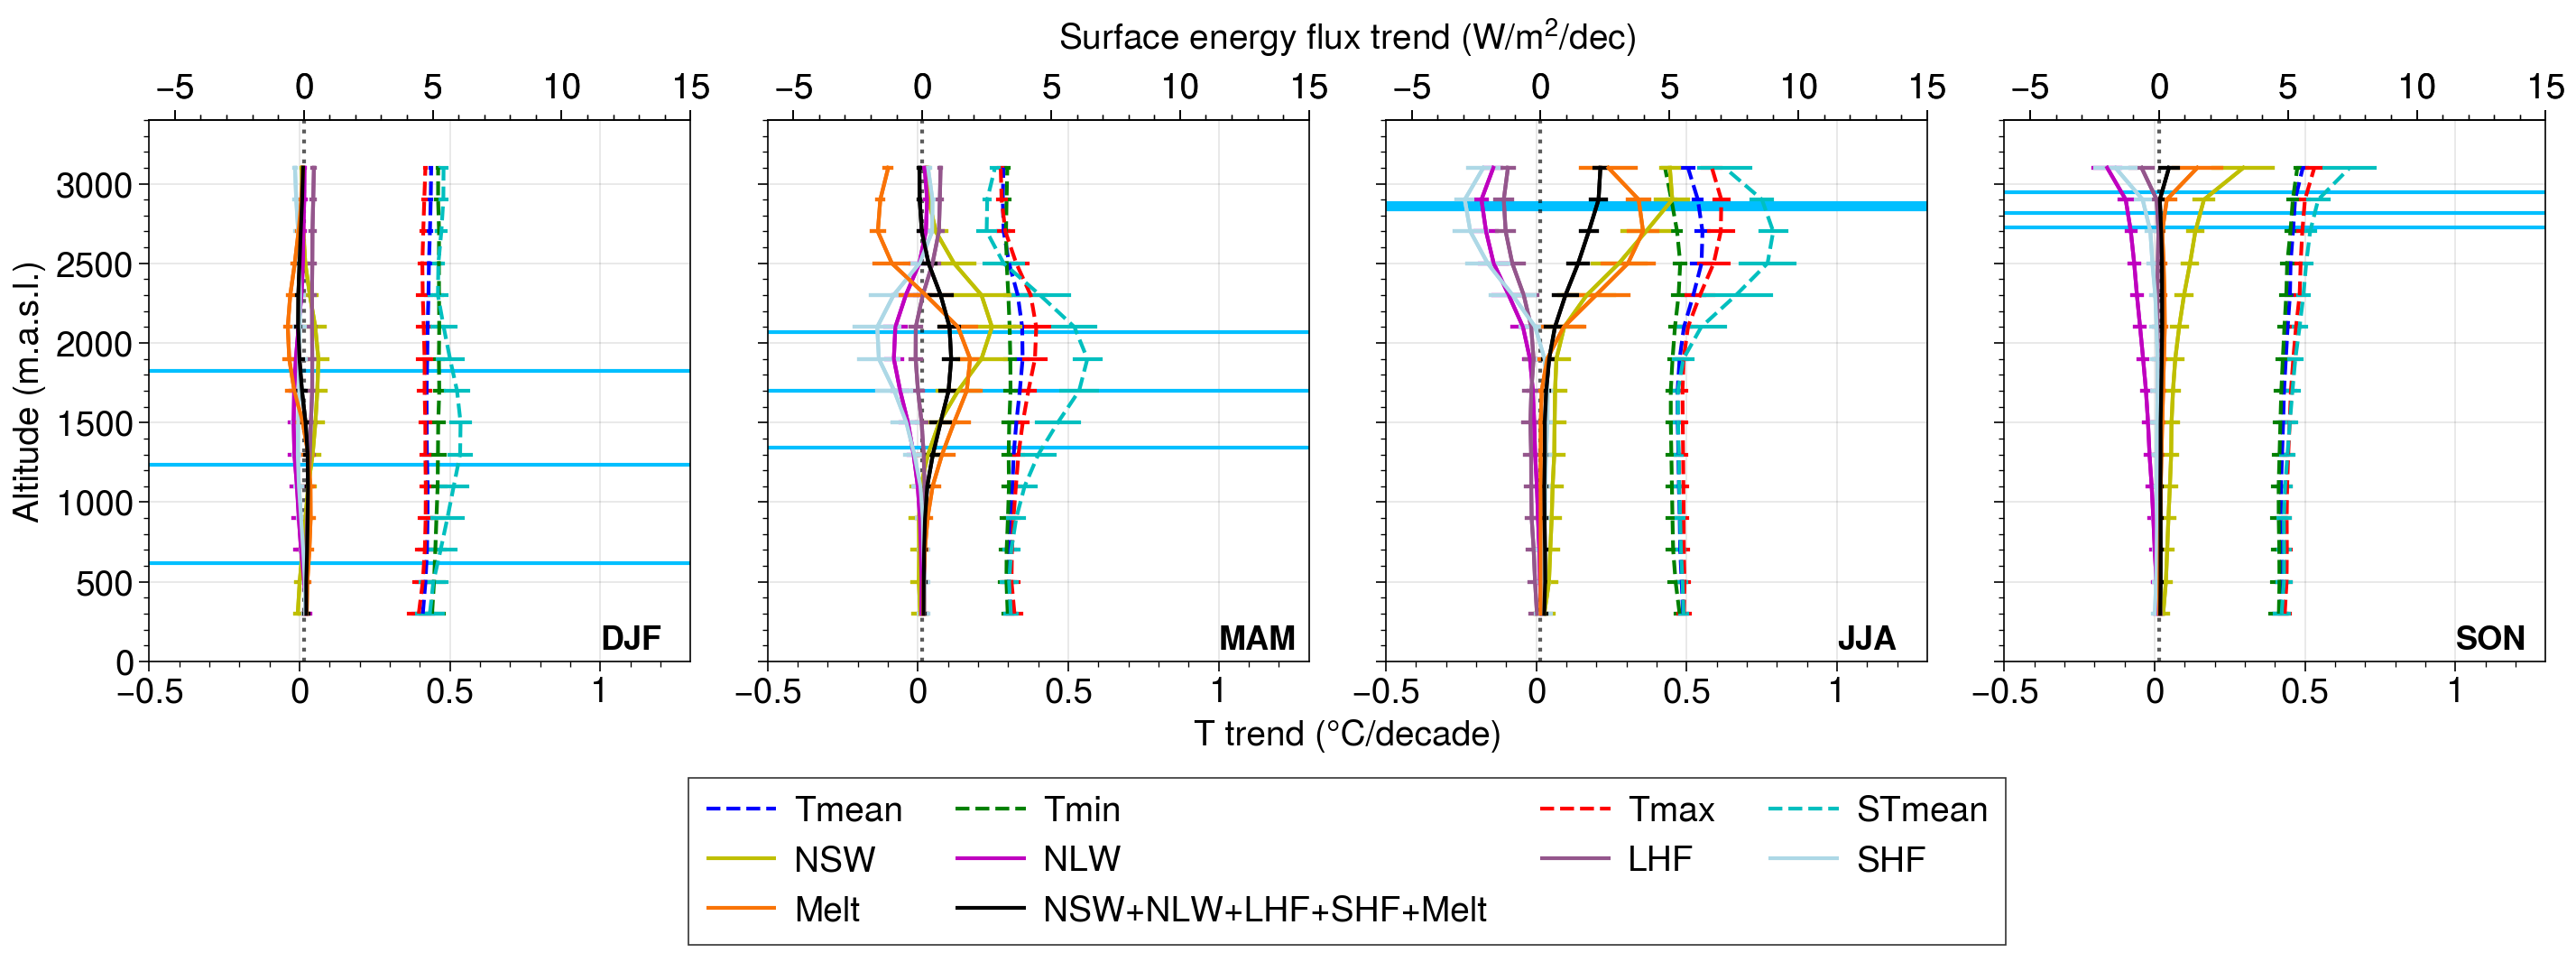

In [59]:
slopes_variables = [slope_T_fut,slope_Tmin_fut,slope_Tmax_fut,slope_ST_fut,slope_NSW_fut,slope_NLW_fut,slope_LHF_fut,slope_SHF_fut,slope_meltflux_fut,
                    slope_energy_balance_fut]

plot_E_balance_and_T(slopes_var=slopes_variables,trend=True,first_year=55,last_year=-1,showlegend=True,snowlines=True)

In [60]:
def plot_E_balance_and_T_1seas(slopes_var=None,trend=True,year=None,first_year=None,last_year=None,showlegend=True,snowlines=False,i=1):
    pplt.rc.update(small=14, large=12)

    n_levels=len(levels)
    n_seas=4
    seasons=['DJF','MAM','JJA','SON']
    #colors = ['b','g','r','c','y','m','purple','lightblue','orange','k']
    colors = ['b','r','c','y','m','purple','lightblue','orange','k']
    leg_labels_null = ['','','','','','','','','','']
    #leg_labels_full = ['Tmean','Tmin','Tmax','STmean','NSW','NLW','LHF','SHF','Melt','NSW+NLW+LHF+SHF+Melt']
    leg_labels_full = ['Tmean','Tmax','STmean','NSW','NLW','LHF','SHF','Melt','NSW+NLW+LHF+SHF+Melt']
    leg_labels = [leg_labels_full,leg_labels_full,leg_labels_full,leg_labels_full]


    with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
        f, axs = pplt.subplots(ncols=1,axwidth=5)
    axs2 = axs.twiny()
    
    mean_slope_T=np.full((n_seas,n_levels),np.nan)
    mean_slope_Tmin=np.full((n_seas,n_levels),np.nan)
    mean_slope_Tmax=np.full((n_seas,n_levels),np.nan)
    mean_slope_ST=np.full((n_seas,n_levels),np.nan)
    mean_slope_NSW=np.full((n_seas,n_levels),np.nan)
    mean_slope_NLW=np.full((n_seas,n_levels),np.nan)
    mean_slope_LHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_SHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_MBm=np.full((n_seas,n_levels),np.nan)
    mean_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    # mean_slopes = [mean_slope_T,mean_slope_Tmin,mean_slope_Tmax,mean_slope_ST,mean_slope_NSW,mean_slope_NLW,mean_slope_LHF,mean_slope_SHF,mean_slope_MBm,
    #                mean_slope_energy_balance]
    mean_slopes = [mean_slope_T,mean_slope_Tmax,mean_slope_ST,mean_slope_NSW,mean_slope_NLW,mean_slope_LHF,mean_slope_SHF,mean_slope_MBm,mean_slope_energy_balance]

    std_slope_T=np.full((n_seas,n_levels),np.nan)
    std_slope_Tmin=np.full((n_seas,n_levels),np.nan)
    std_slope_Tmax=np.full((n_seas,n_levels),np.nan)
    std_slope_ST=np.full((n_seas,n_levels),np.nan)
    std_slope_NSW=np.full((n_seas,n_levels),np.nan)
    std_slope_NLW=np.full((n_seas,n_levels),np.nan)
    std_slope_LHF=np.full((n_seas,n_levels),np.nan)
    std_slope_SHF=np.full((n_seas,n_levels),np.nan)
    std_slope_MBm=np.full((n_seas,n_levels),np.nan)
    std_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    # std_slopes = [std_slope_T,std_slope_Tmin,std_slope_Tmax,std_slope_ST,std_slope_NSW,std_slope_NLW,std_slope_LHF,std_slope_SHF,std_slope_MBm,
    #               std_slope_energy_balance]
    std_slopes = [std_slope_T,std_slope_Tmax,std_slope_ST,std_slope_NSW,std_slope_NLW,std_slope_LHF,std_slope_SHF,std_slope_MBm,std_slope_energy_balance]

    #wp_meanseason_vars = [wp_meanseason_meanT,wp_meanseason_minT,wp_meanseason_maxT,wp_meanseason_ST,wp_meanseason_meanNSW,wp_meanseason_NLW,wp_meanseason_LHF,
    #                      wp_meanseason_SHF,wp_meanseason_meltflux,wp_meanseason_energy_balance]
    wp_meanseason_vars = [wp_meanseason_meanT,wp_meanseason_maxT,wp_meanseason_ST,wp_meanseason_meanNSW,wp_meanseason_NLW,wp_meanseason_LHF,
                          wp_meanseason_SHF,wp_meanseason_meltflux,wp_meanseason_energy_balance]
    

    ax = axs[0]
    ax2 = axs2[0]
    
    for var in range(len(wp_meanseason_vars)):
        for j in range(n_levels): # levels
            if trend:
                slope_var = np.ma.masked_array(slopes_var[var][i], mask=np.invert(levels[j])).reshape(12649)
                multiplier = 10 # trends per decade so we x10
            elif first_year != None: # not a trend, but averaging over first_year:last_year
                slope_var = np.ma.masked_array(wp_meanseason_vars[var][first_year:last_year,i].mean(axis=0), mask=np.invert(levels[j])).reshape(12649)
                multiplier = 1
            else: # taking one year in particular
                slope_var = np.ma.masked_array(wp_meanseason_vars[var][year-1961,i], mask=np.invert(levels[j])).reshape(12649)
                multiplier = 1
            
            mean_slopes[var][i,j] = multiplier*slope_var.mean()
            std_slopes[var][i,j] = multiplier*slope_var.std()
            if var<3: # change here if you change the variables you want to show
                ax.plot([multiplier*slope_var.mean()-multiplier*slope_var.std(),multiplier*slope_var.mean()+multiplier*slope_var.std()],[H_levels[j],H_levels[j]],c=colors[var])
            else:
                ax2.plot([multiplier*slope_var.mean()-multiplier*slope_var.std(),multiplier*slope_var.mean()+multiplier*slope_var.std()],[H_levels[j],H_levels[j]],c=colors[var])
        if var<3: # change here if you change the variables you want to show
            ax.plot(mean_slopes[var][i,:],H_levels,c=colors[var],linestyle='--',label=leg_labels[i][var])
        else:
            ax2.plot(mean_slopes[var][i,:],H_levels,c=colors[var],label=leg_labels[i][var])


    if trend:
        ax.set_xlim(-0.5,0.7)
        ax.text(0.55, 75, seasons[i], fontsize=13,fontweight='semibold')
    else:
        ax.set_xlim(-55.,35)
        ax.text(20, 75, seasons[i], fontsize=13,fontweight='semibold')

        ax.set_ylim(0,3400)
        
    if snowlines:
        #ax.hlines(mean1_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
        #ax.hlines(mean1_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
        #ax.hlines(mean1_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
        ax.hlines(mean10_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
        ax.hlines(mean10_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
        ax.hlines(mean10_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
        
    ax2.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    #ax2.plot(mean_slope_NSW[i,:]+mean_slope_NLW[i,:]+mean_slope_LHF[i,:]+mean_slope_SHF[i,:],H_levels,c='k',linestyle='--')

    if trend:
        ax2.set_xlim(-5,15)
    else:
        ax2.set_xlim(-90,320)
        

    if showlegend:
        f.legend(loc='b',prop = { "size": 12 },ncols=4)
    
    if trend:
        xLabel = 'T trend (°C/decade)'
        Suptitle='Surface energy flux trend (W/$m^2$/dec)'
    else:
        xLabel = 'T (°C)'
        Suptitle='Surface energy flux (W/$m^2$)'

    if year != None:
        axs[0].text(x=10,y=3000,s=f'Year = {year}')
    axs.format(xlabel=xLabel,ylabel='Altitude (m.a.s.l.)',suptitle=Suptitle)

/tmp/ipykernel_603715/2196713051.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/2196713051.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


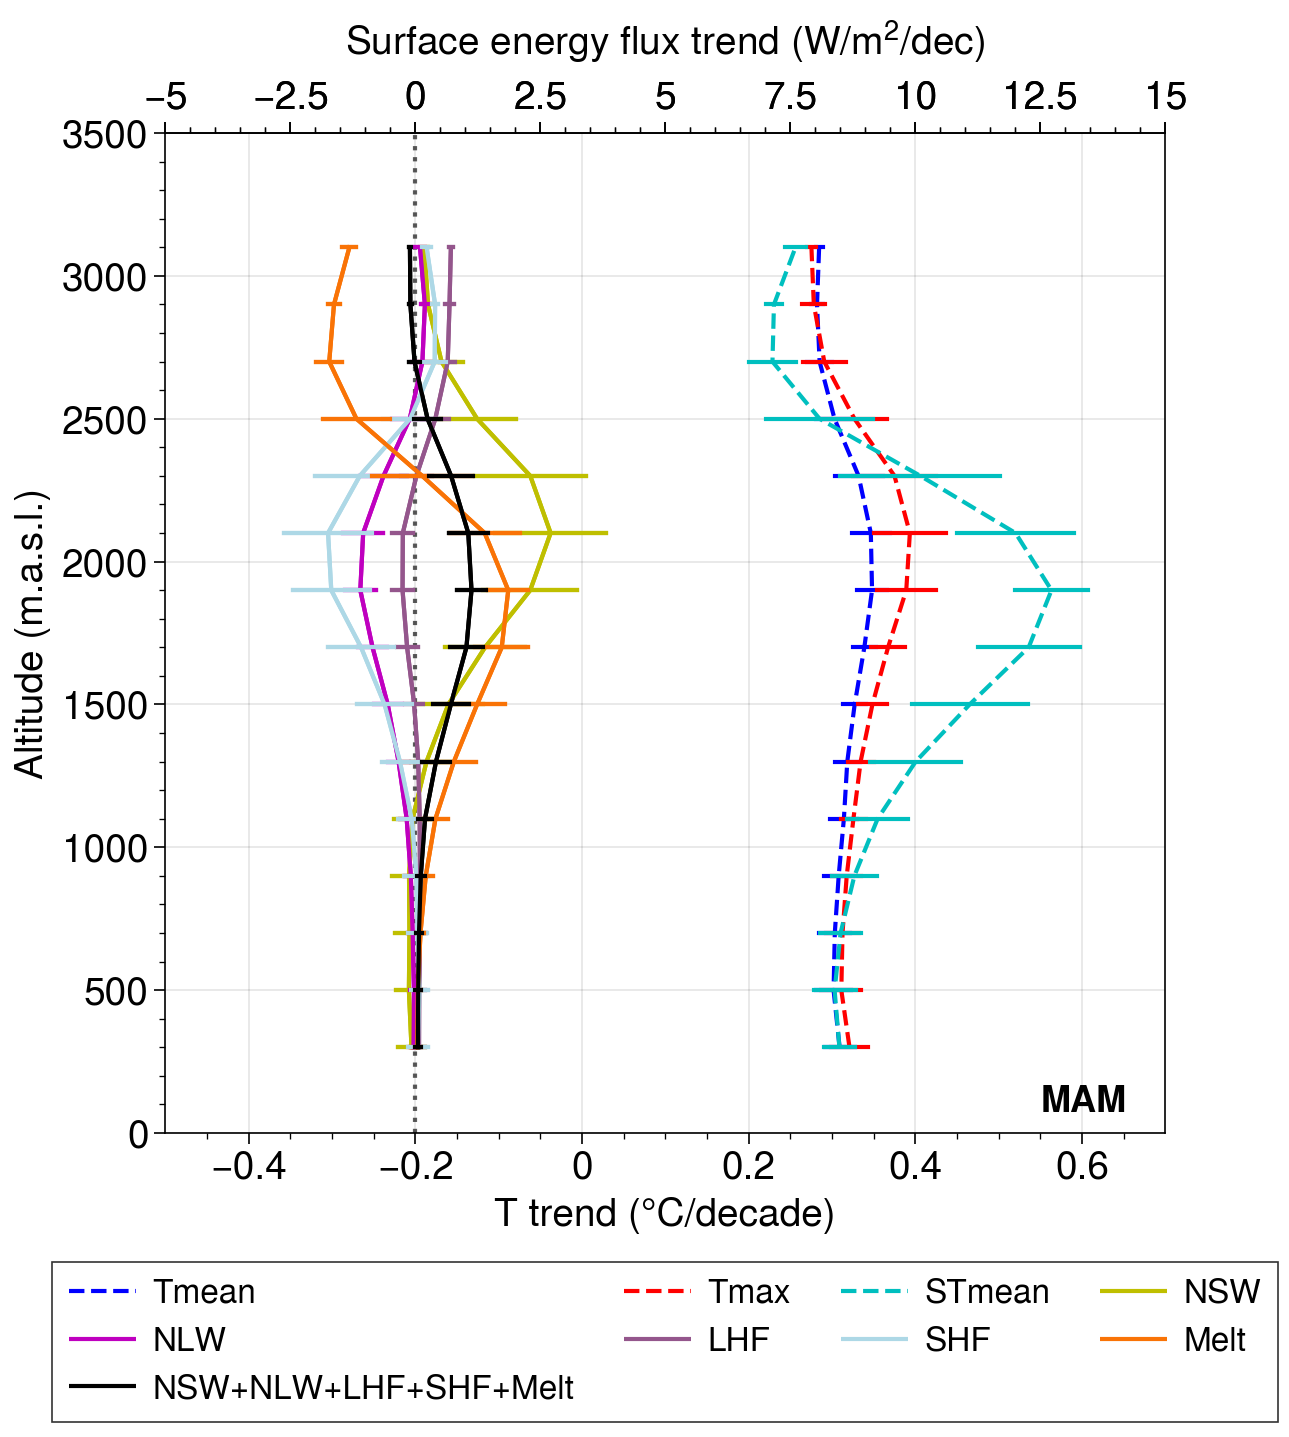

In [61]:
#slopes_variables = [slope_T_fut,slope_Tmin_fut,slope_Tmax_fut,slope_ST_fut,slope_NSW_fut,slope_NLW_fut,slope_LHF_fut,slope_SHF_fut,slope_meltflux_fut,
#                    slope_energy_balance_fut]
slopes_variables = [slope_T_fut,slope_Tmax_fut,slope_ST_fut,slope_NSW_fut,slope_NLW_fut,slope_LHF_fut,slope_SHF_fut,slope_meltflux_fut,
                    slope_energy_balance_fut]

plot_E_balance_and_T_1seas(slopes_var=slopes_variables,trend=True,first_year=55,last_year=-1,showlegend=True,snowlines=False)

/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


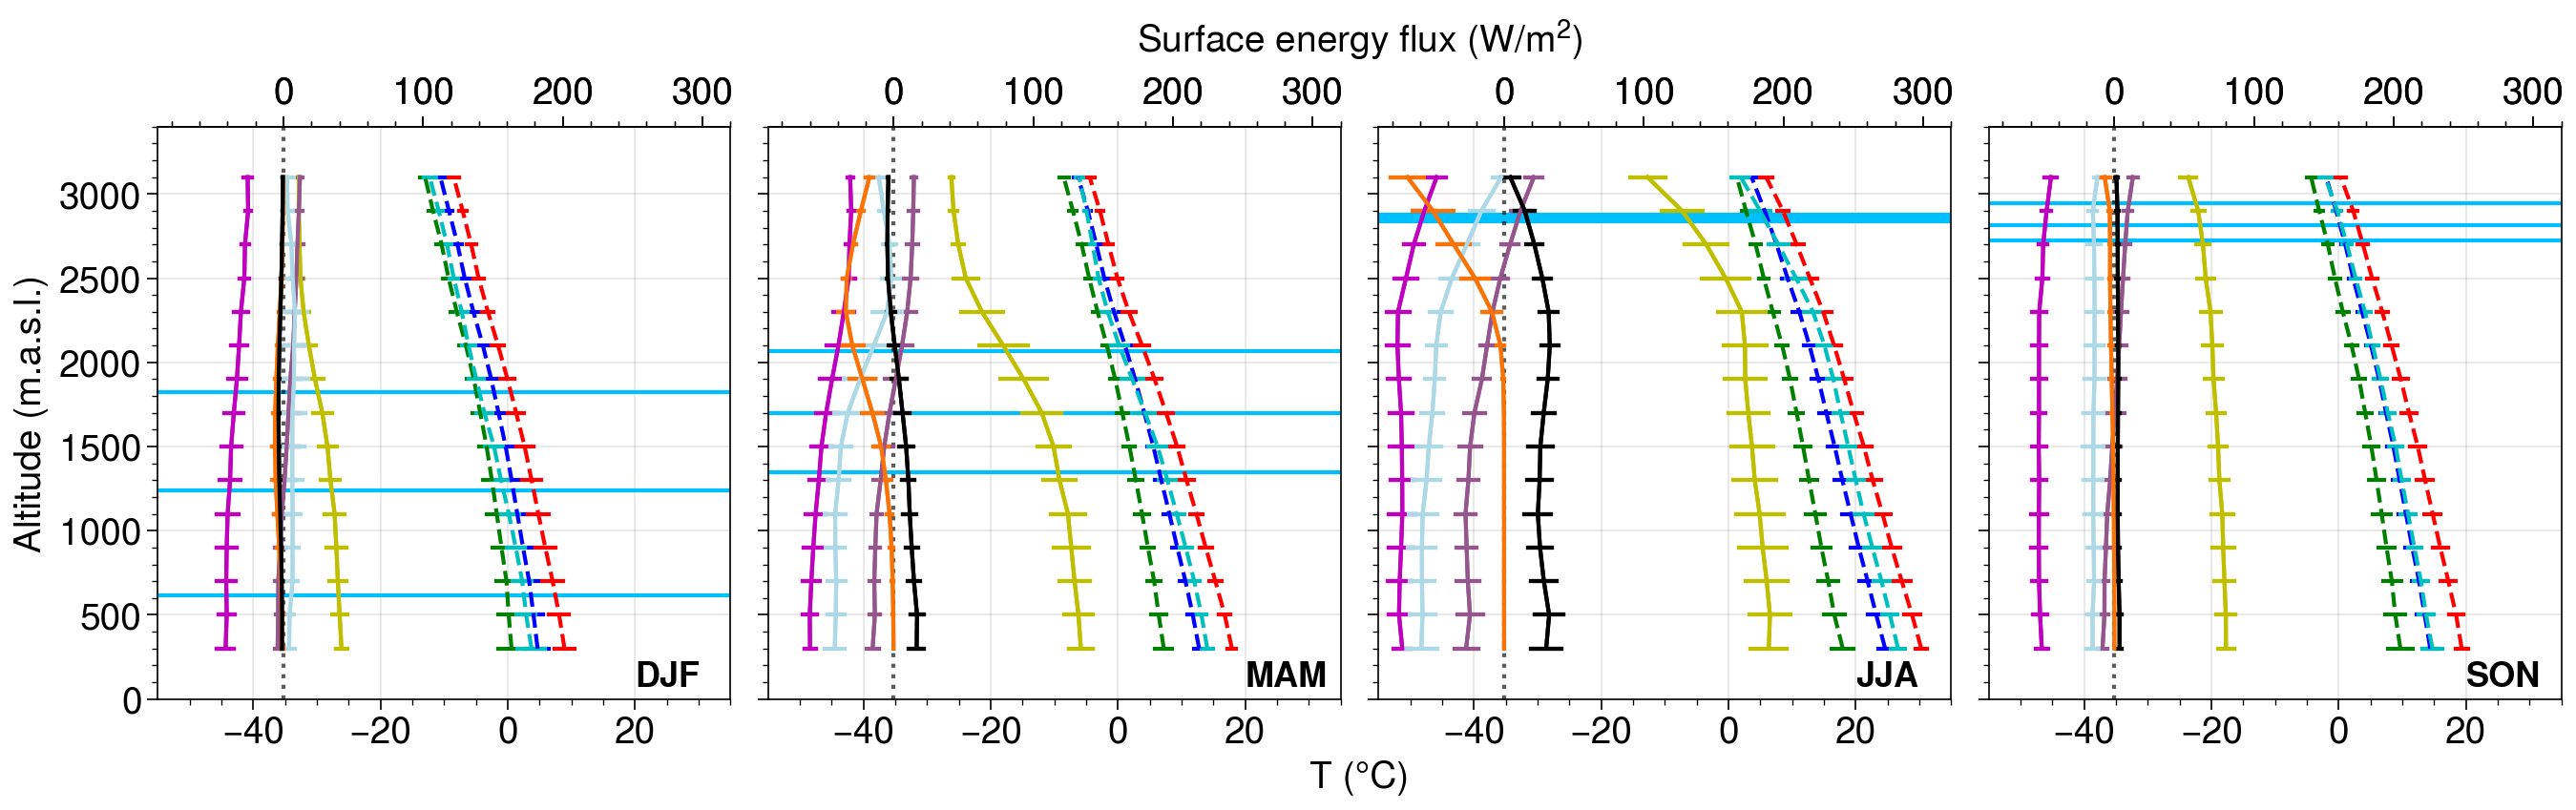

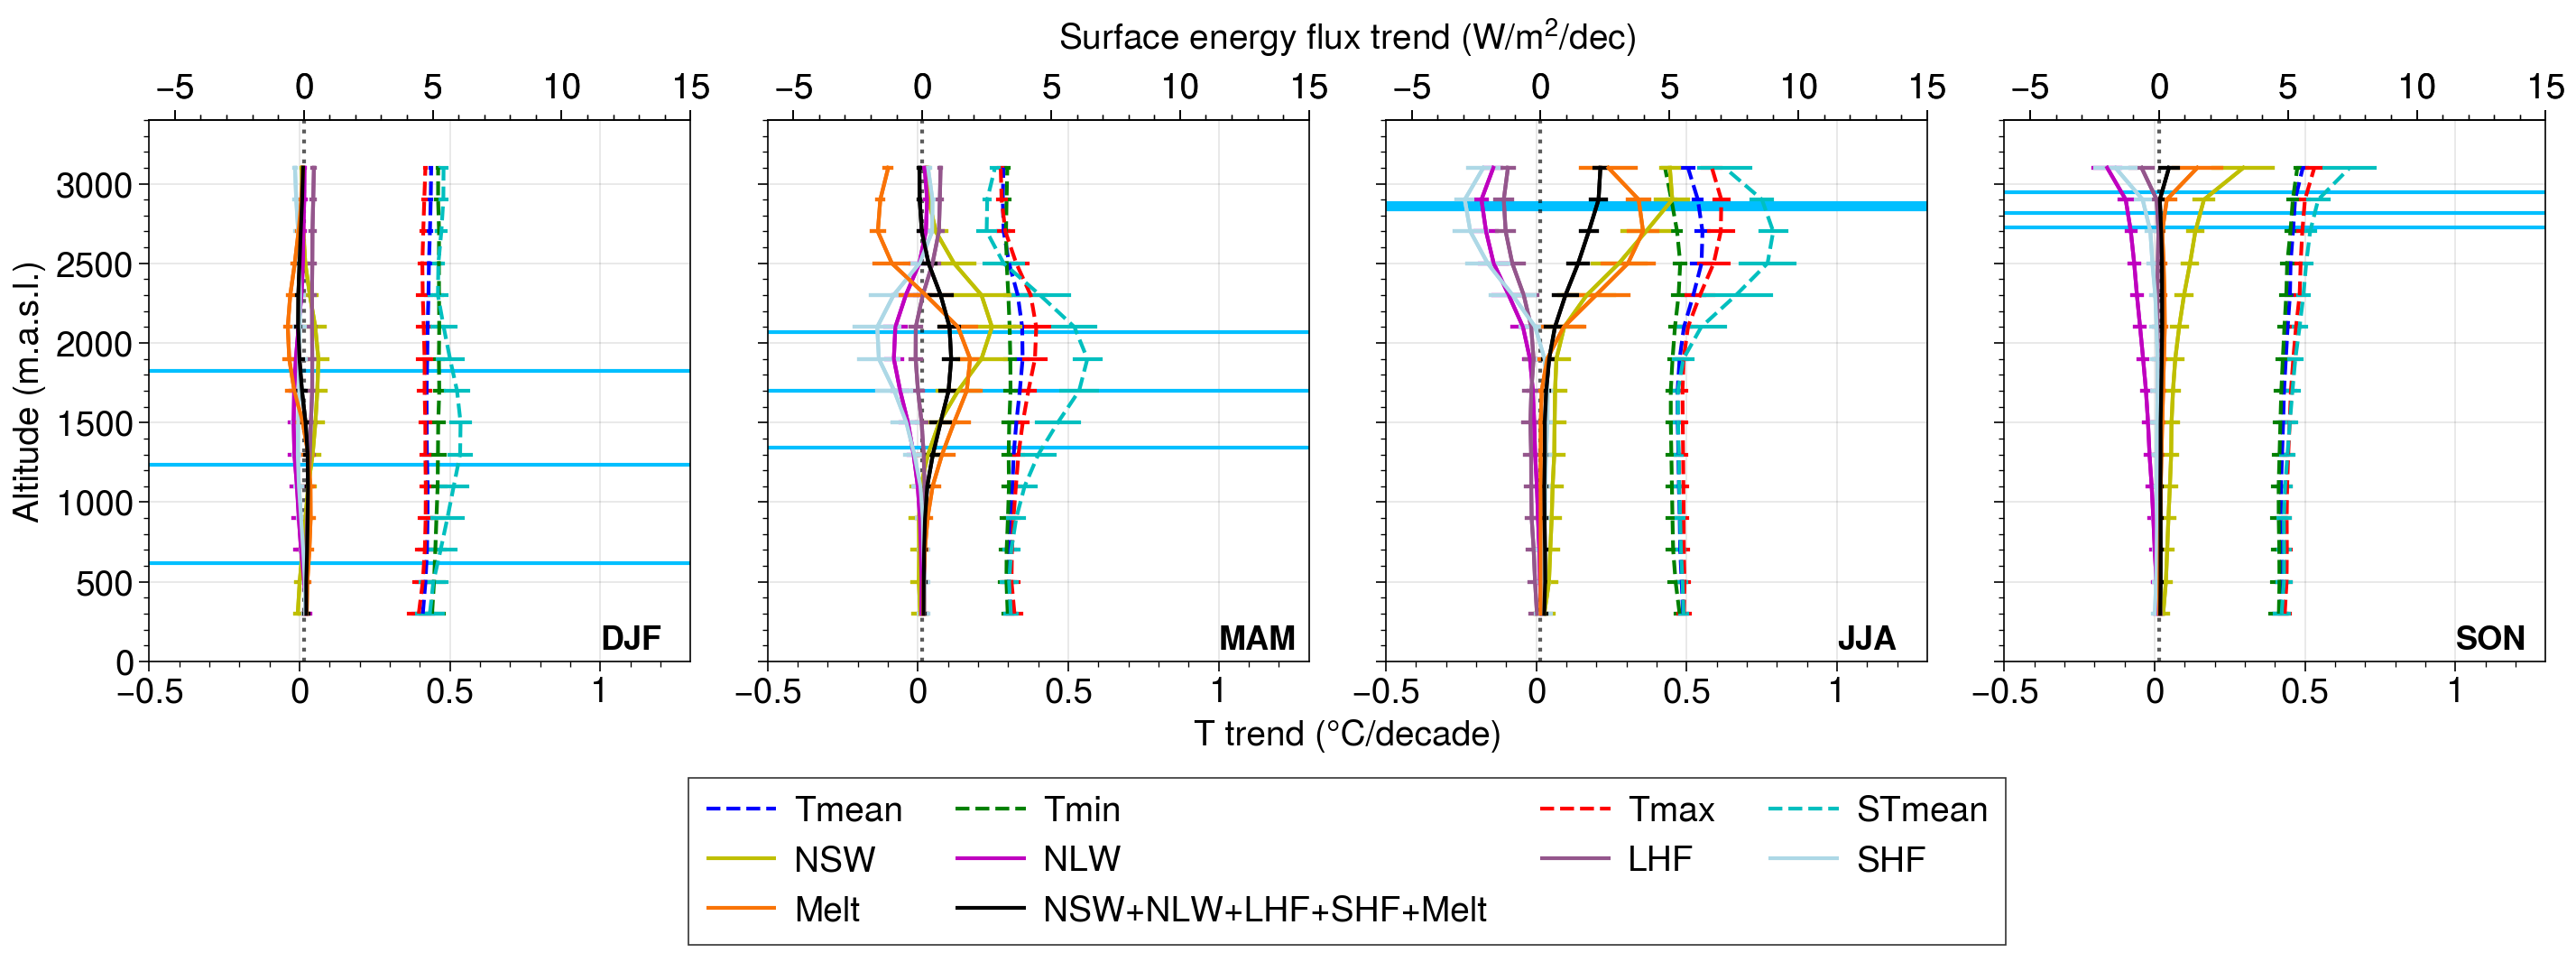

In [62]:
plot_E_balance_and_T(slopes_var=None,trend=False,first_year=55,last_year=-1,showlegend=False,snowlines=True)

slopes_variables = [slope_T_fut,slope_Tmin_fut,slope_Tmax_fut,slope_ST_fut,slope_NSW_fut,slope_NLW_fut,slope_LHF_fut,slope_SHF_fut,slope_meltflux_fut,
                    slope_energy_balance_fut]
plot_E_balance_and_T(slopes_var=slopes_variables,trend=True,first_year=55,last_year=-1,showlegend=True,snowlines=True)

/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


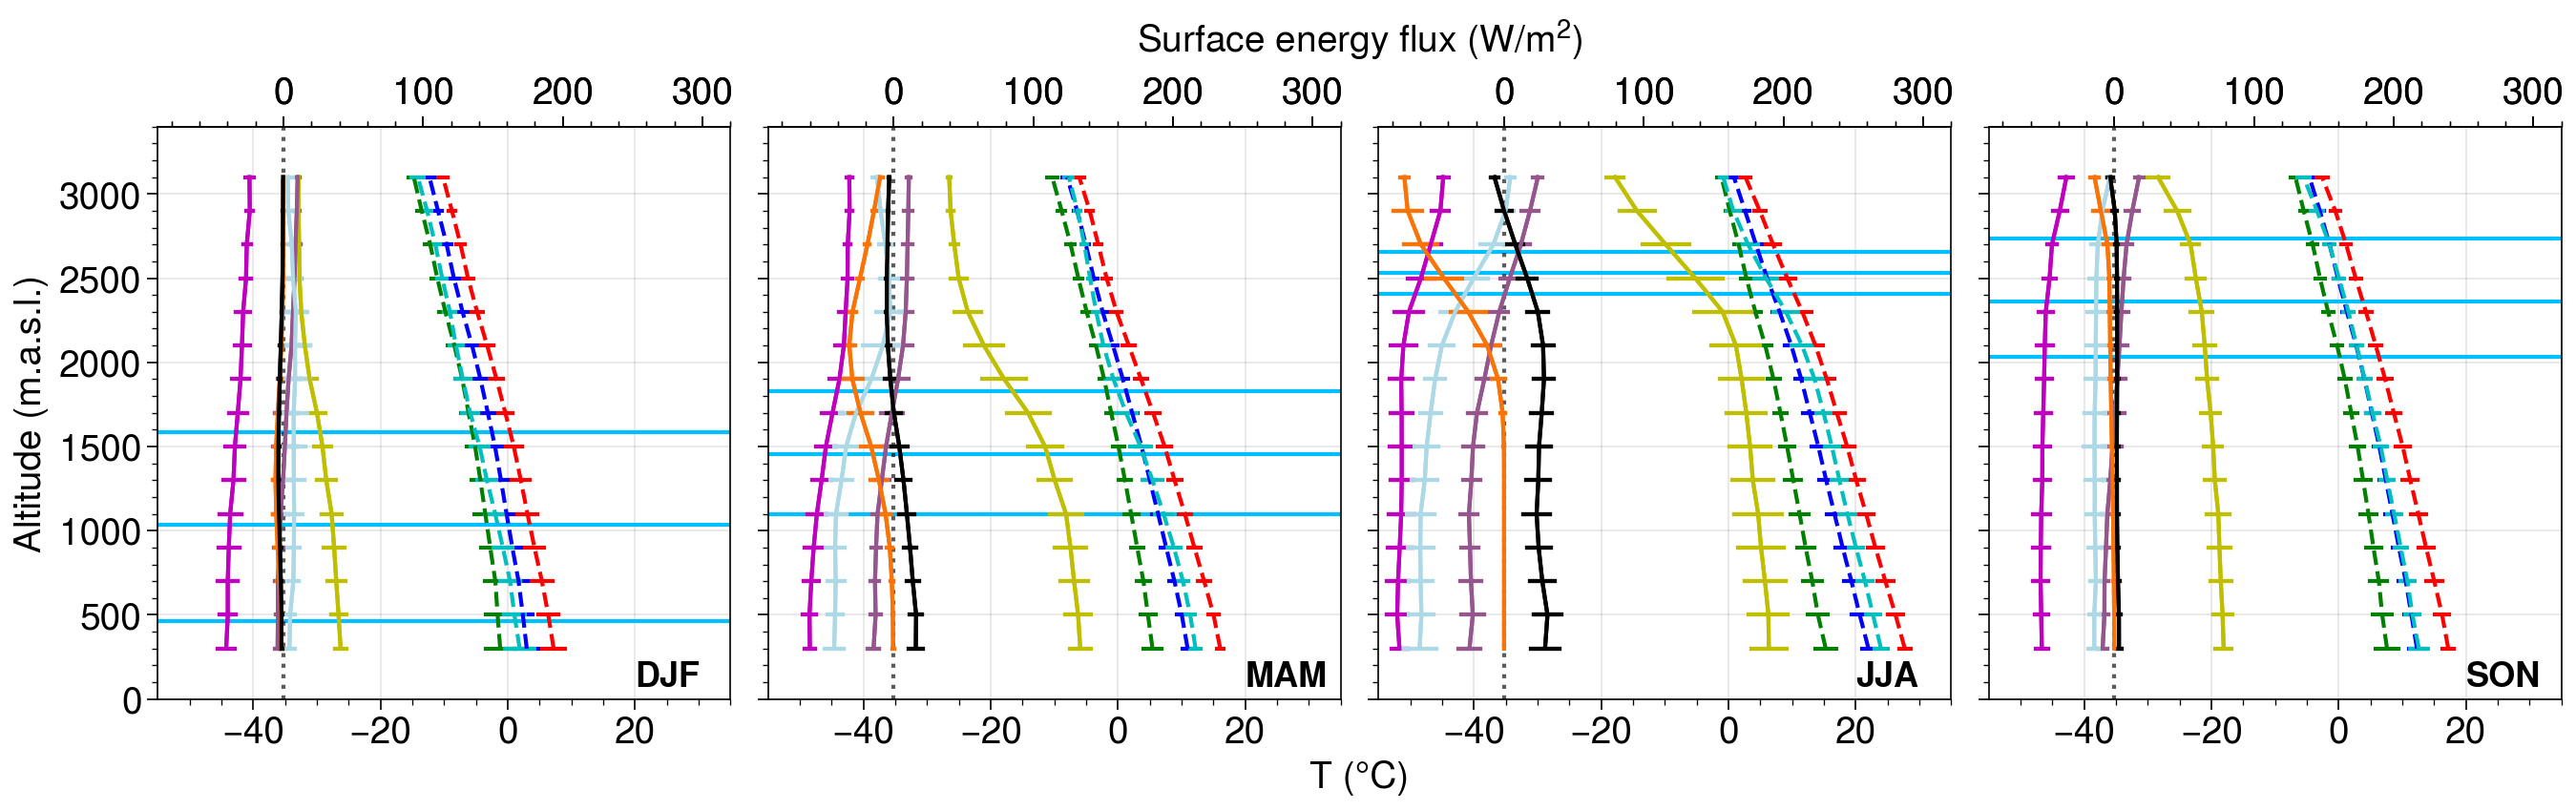

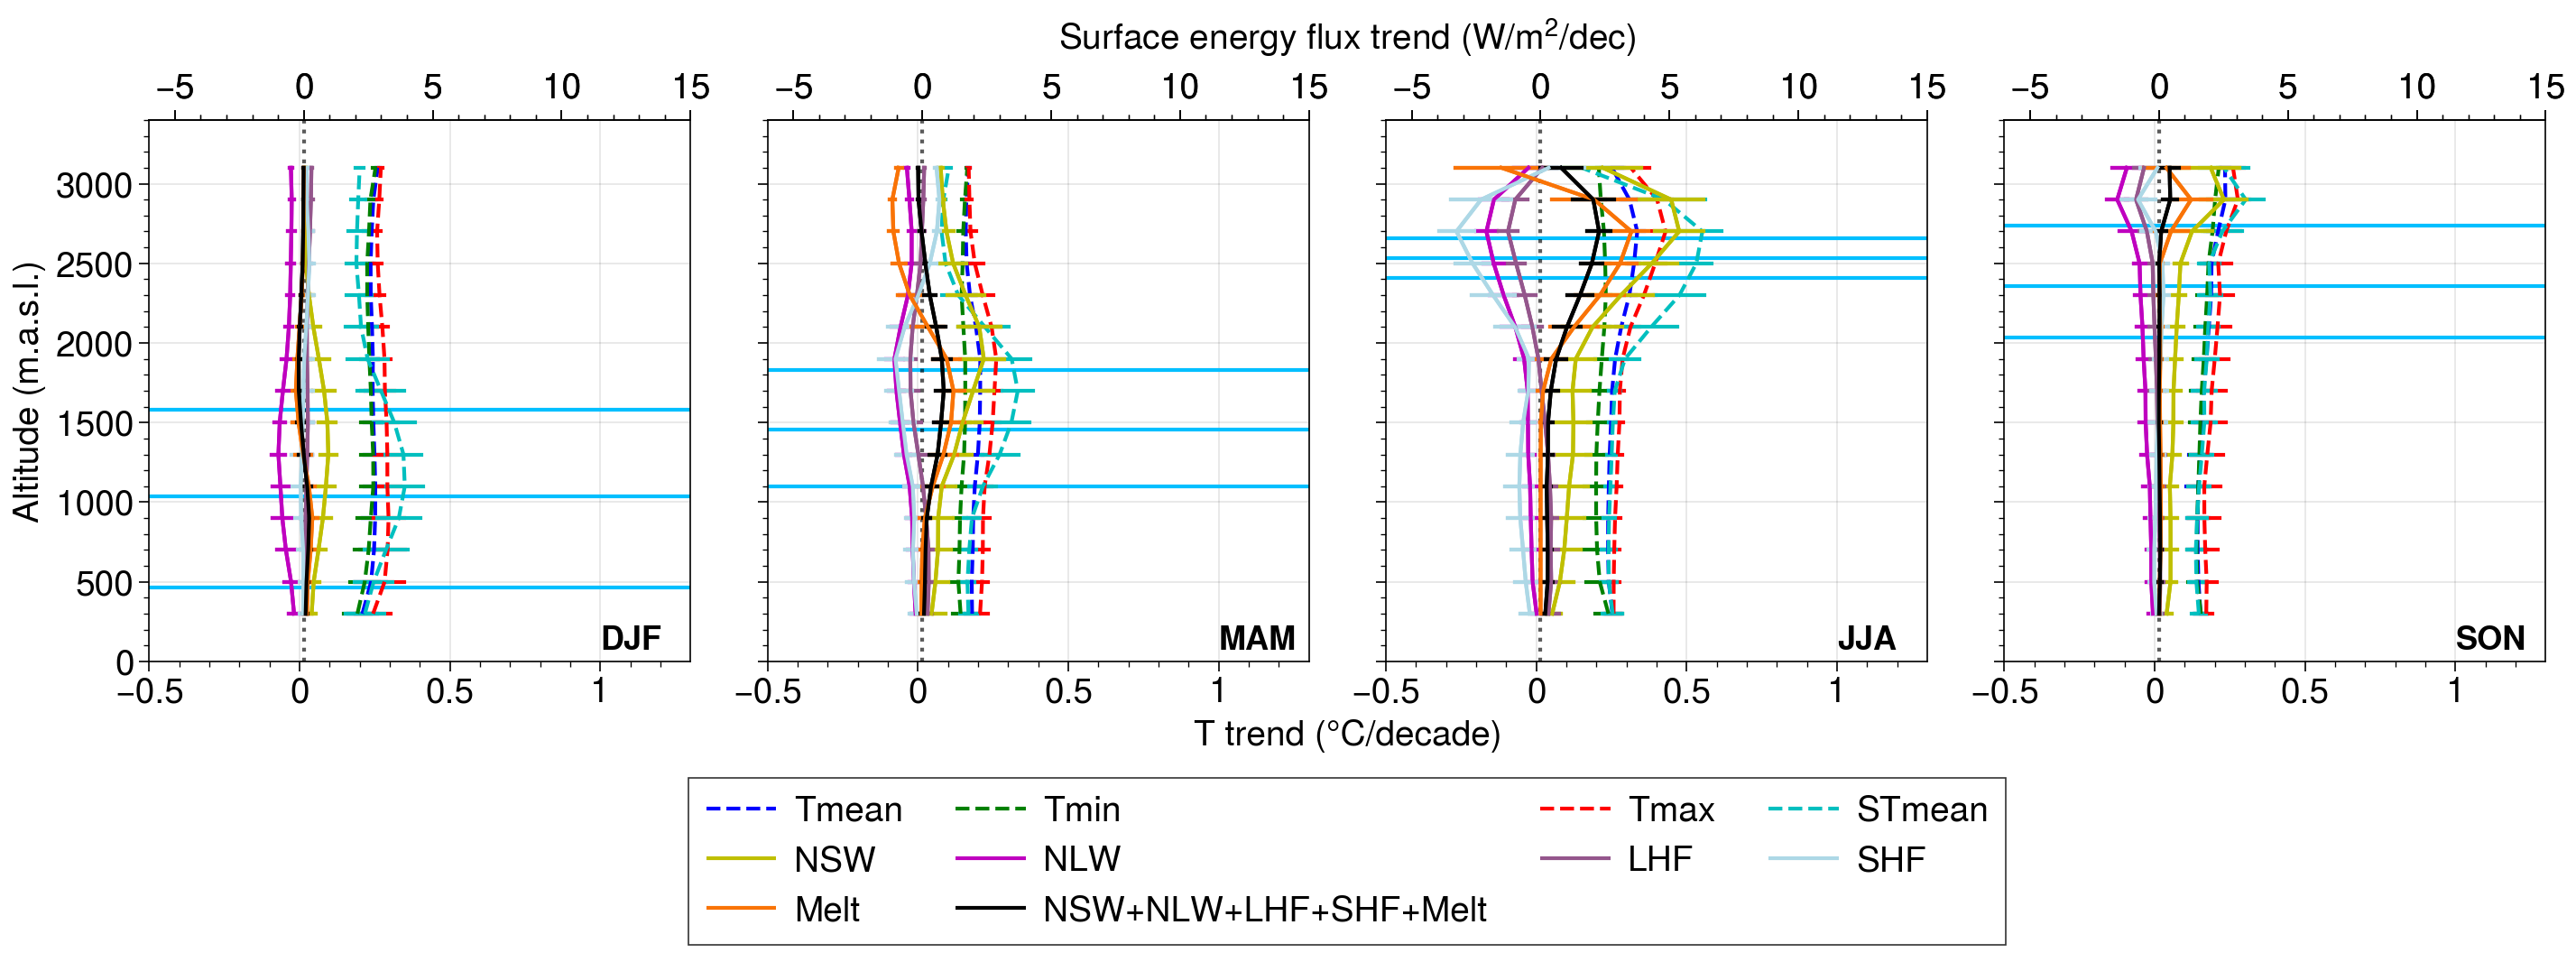

In [63]:
# Hist

plot_E_balance_and_T(slopes_var=None,trend=False,first_year=0,last_year=55,showlegend=False,snowlines=True)

slopes_variables = [slope_T_hist,slope_Tmin_hist,slope_Tmax_hist,slope_ST_hist,slope_NSW_hist,slope_NLW_hist,slope_LHF_hist,slope_SHF_hist,slope_meltflux_hist,
                    slope_energy_balance_hist]
plot_E_balance_and_T(slopes_var=slopes_variables,trend=True,first_year=0,last_year=55,showlegend=True,snowlines=True)

/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


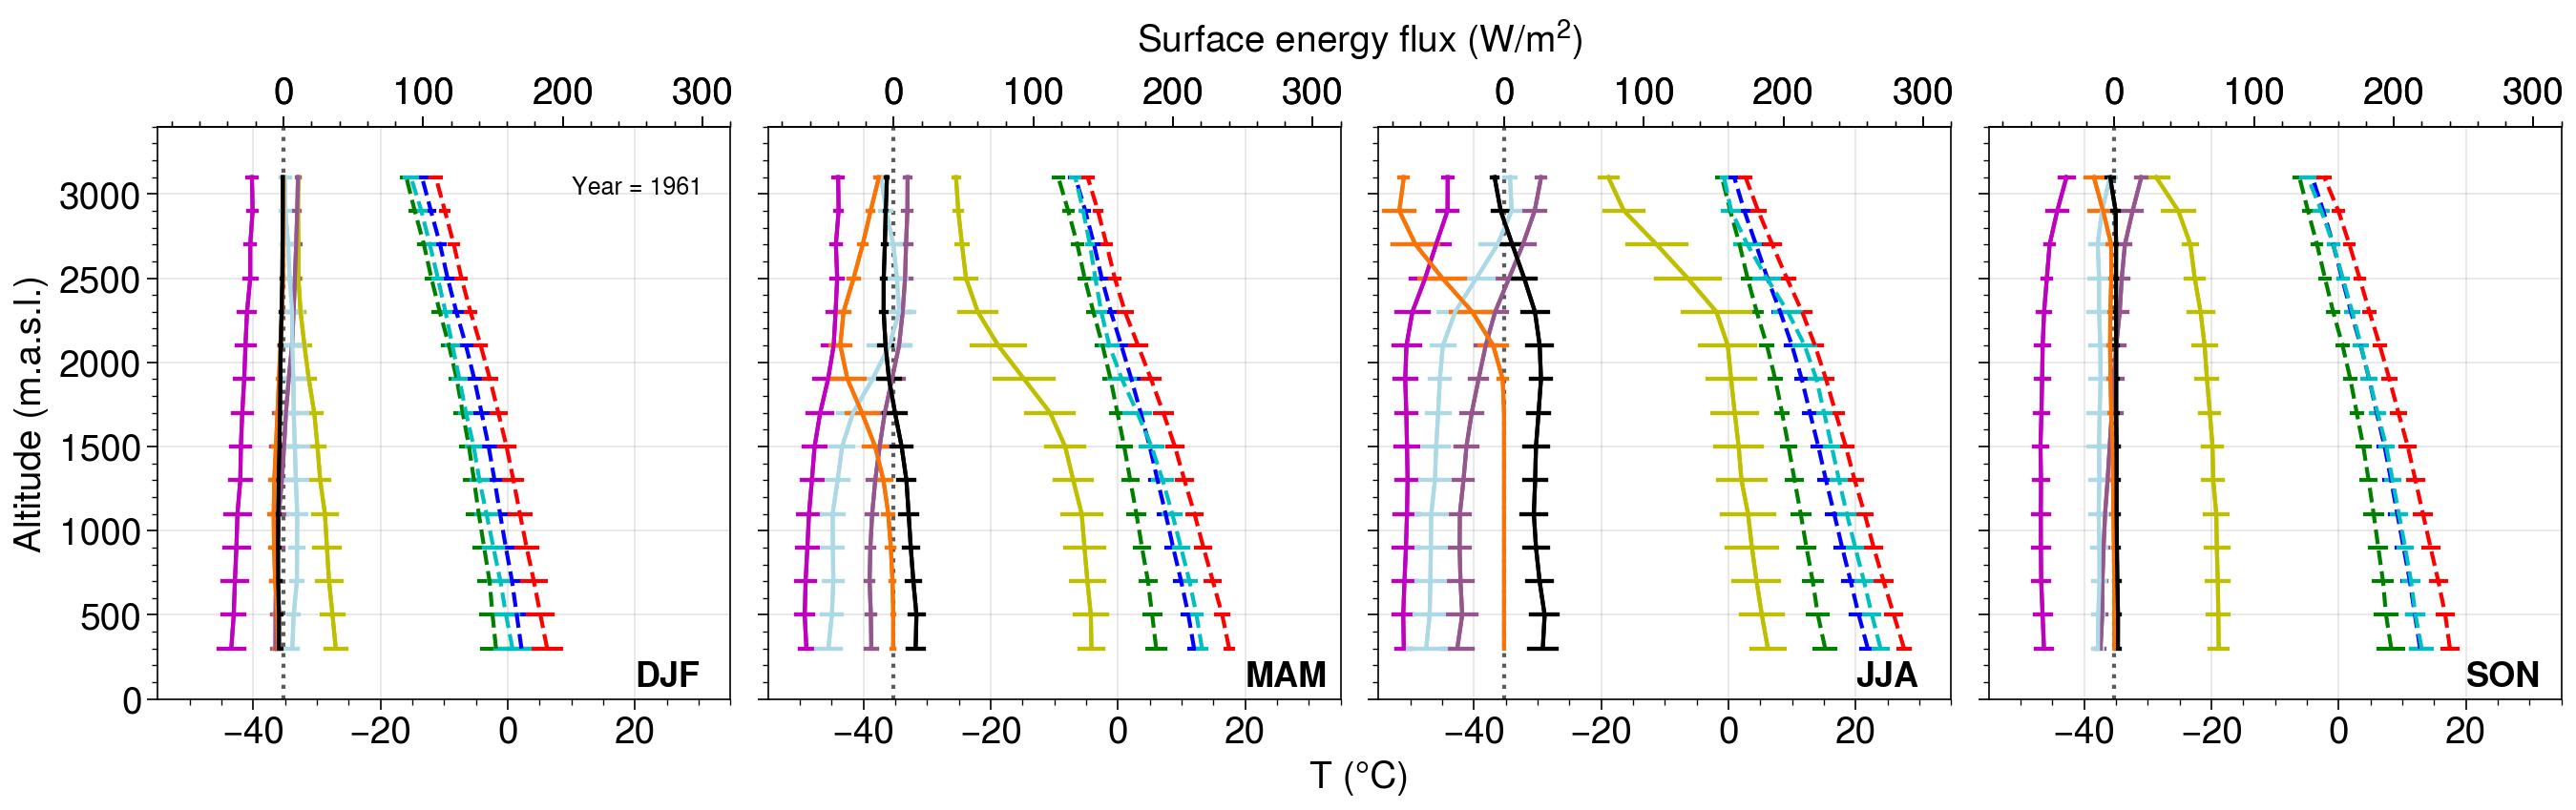

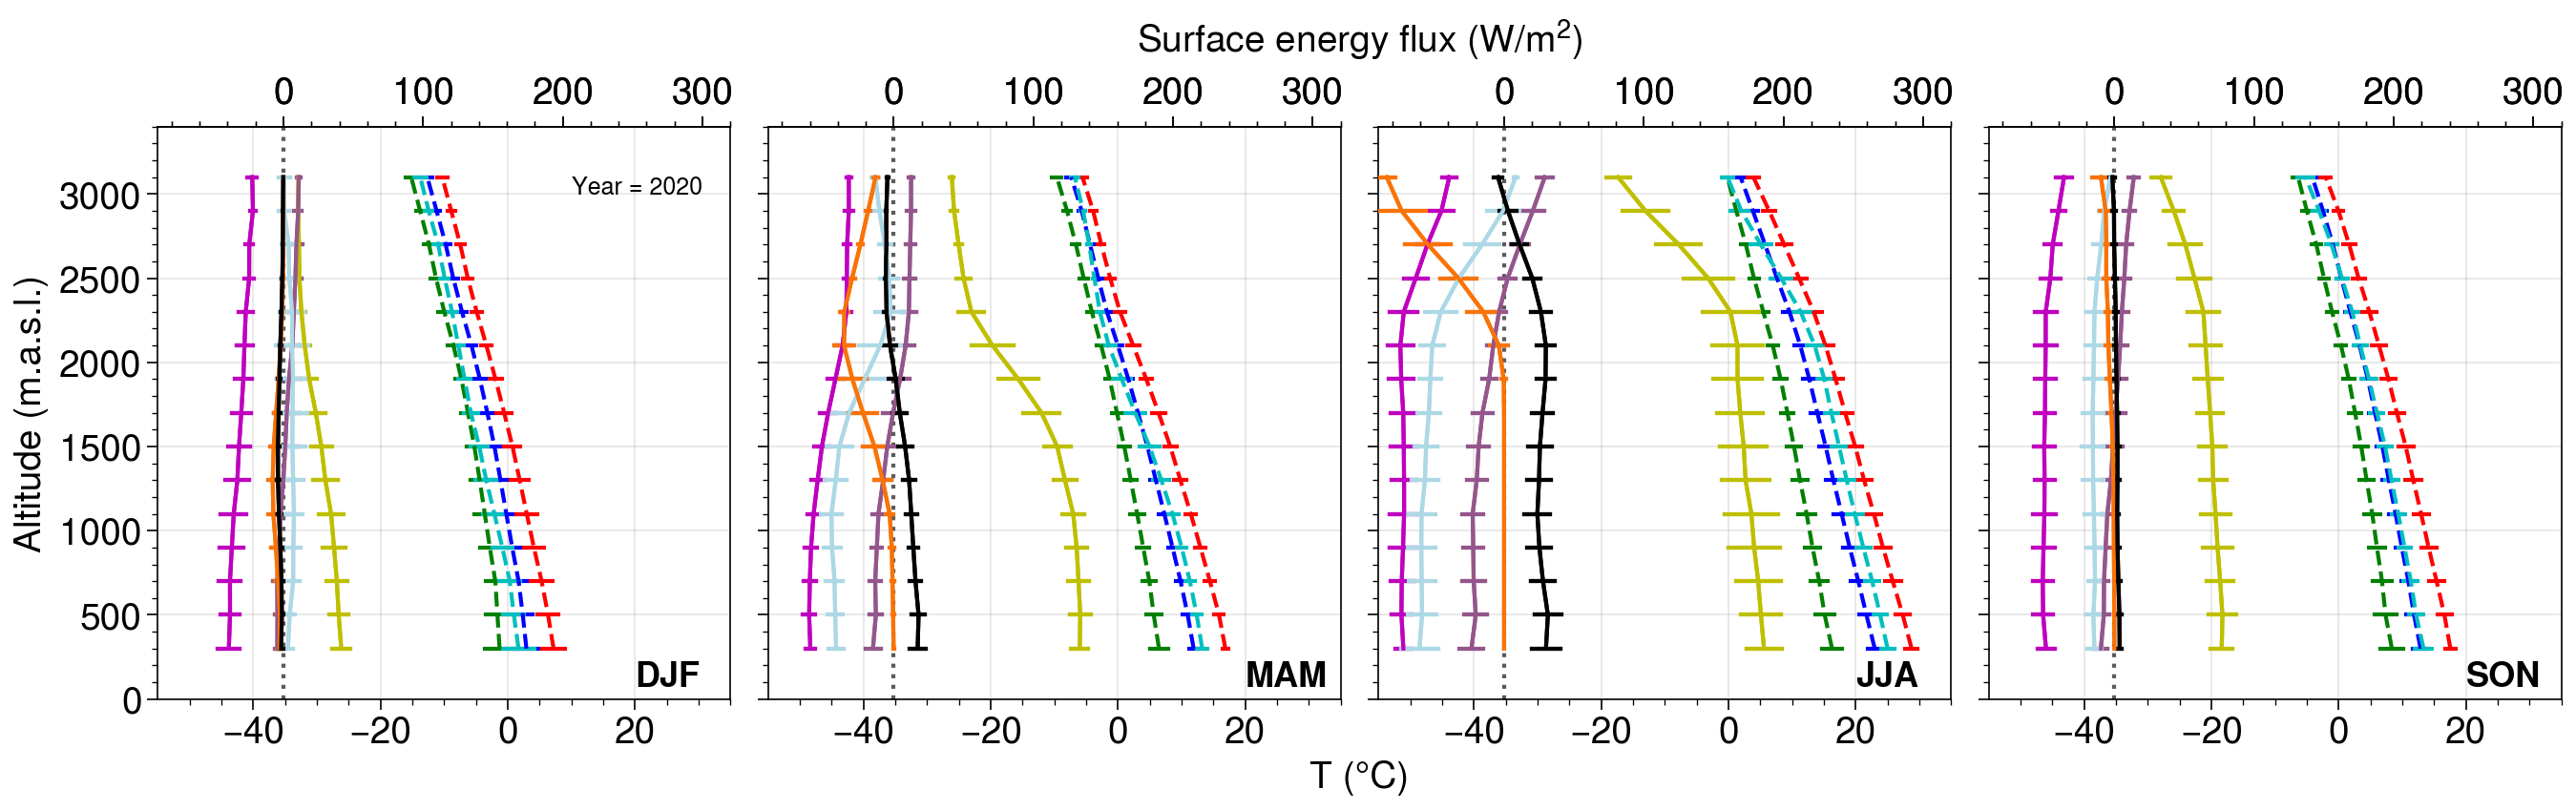

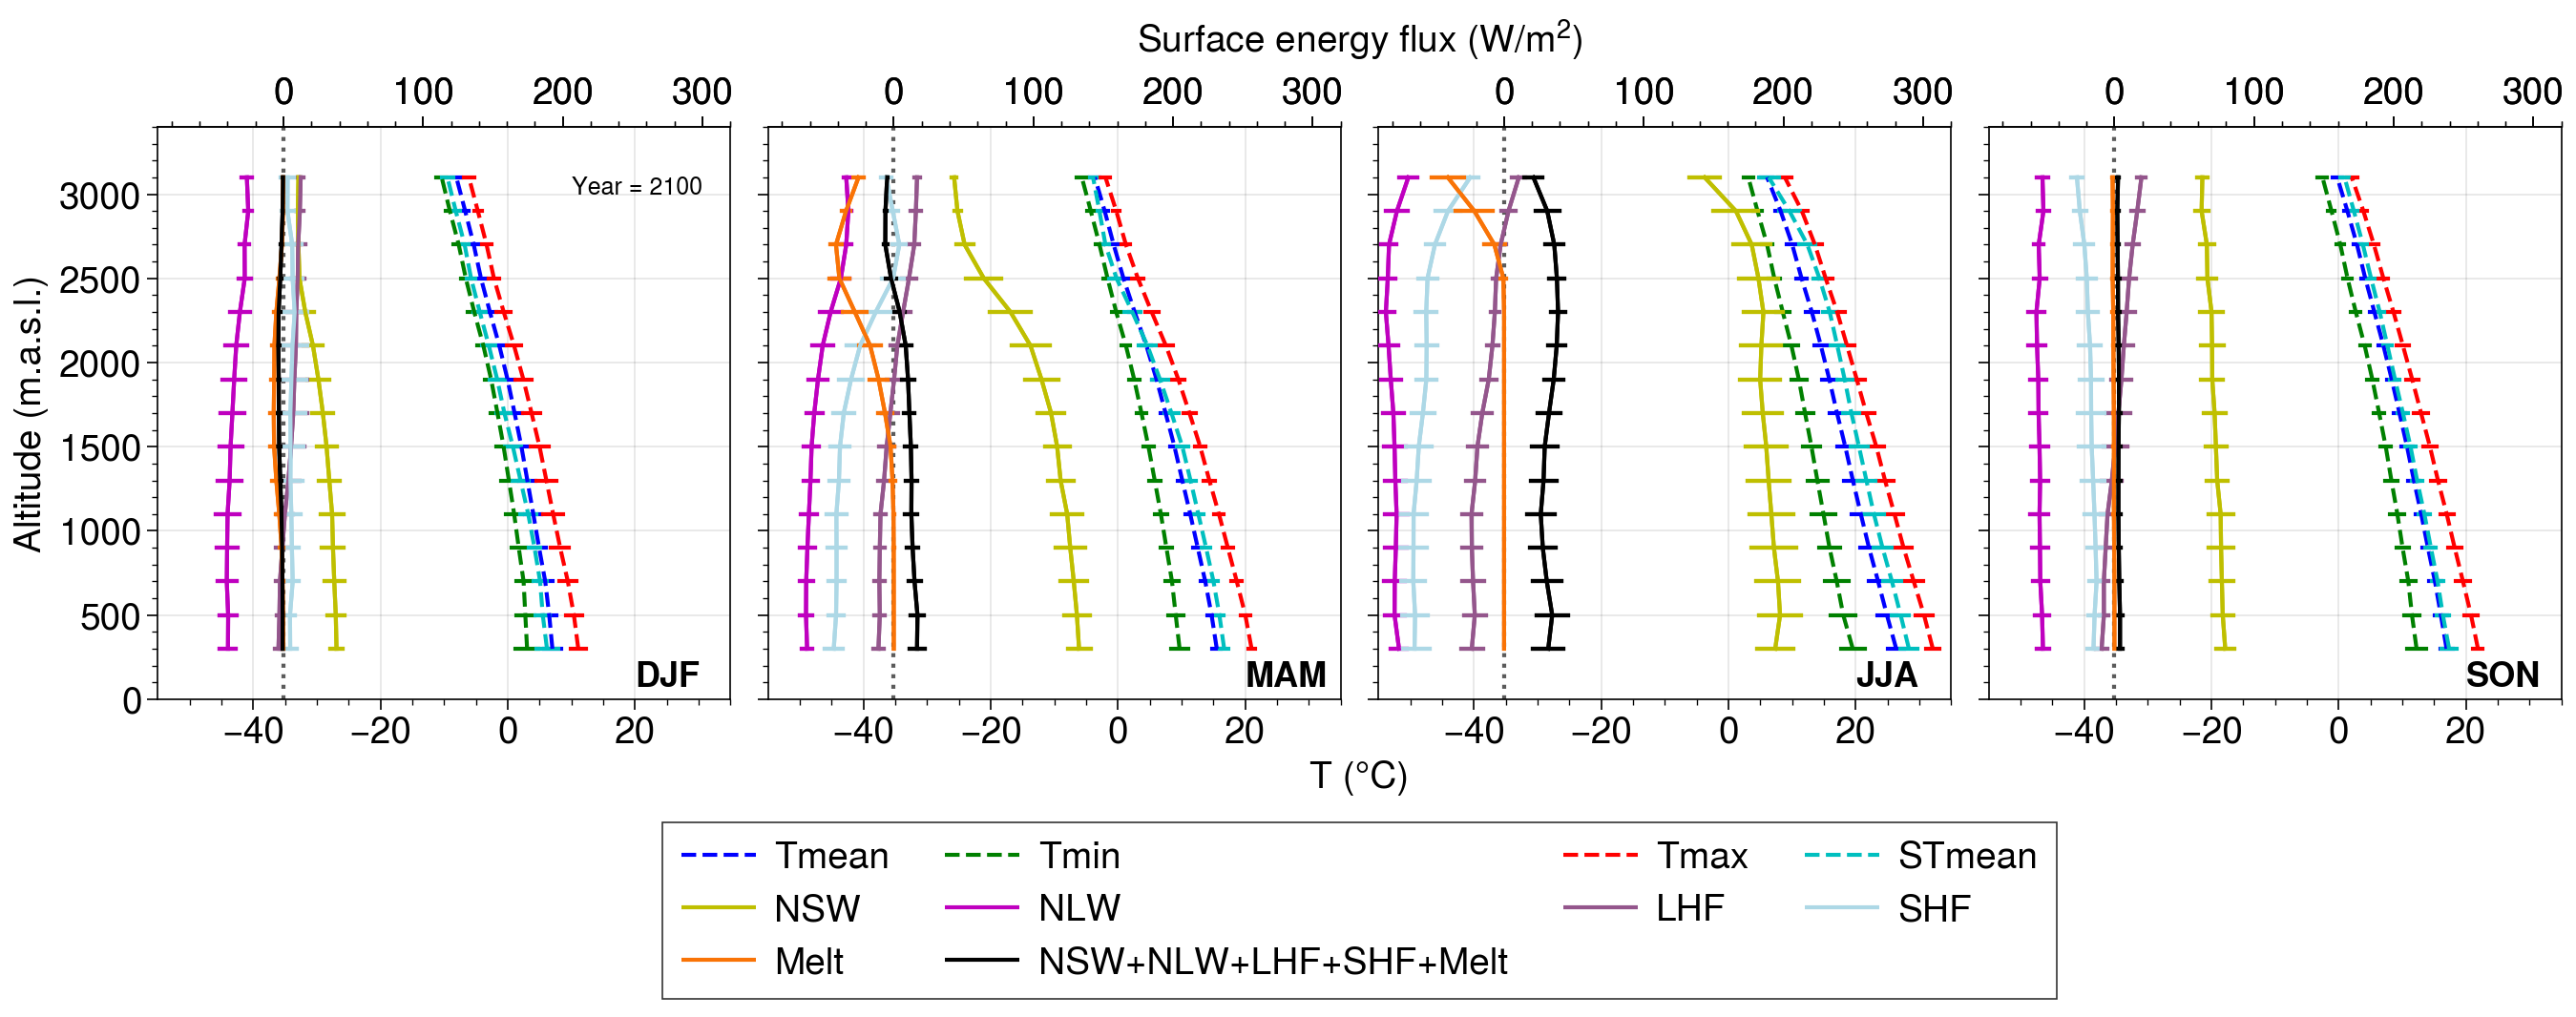

In [64]:
### For just one year

plot_E_balance_and_T(slopes_var=None,trend=False,year=1961,showlegend=False,snowlines=False)

plot_E_balance_and_T(slopes_var=None,trend=False,year=2020,showlegend=False,snowlines=False)

plot_E_balance_and_T(slopes_var=None,trend=False,year=2100,showlegend=True,snowlines=False)


/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1509513082.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


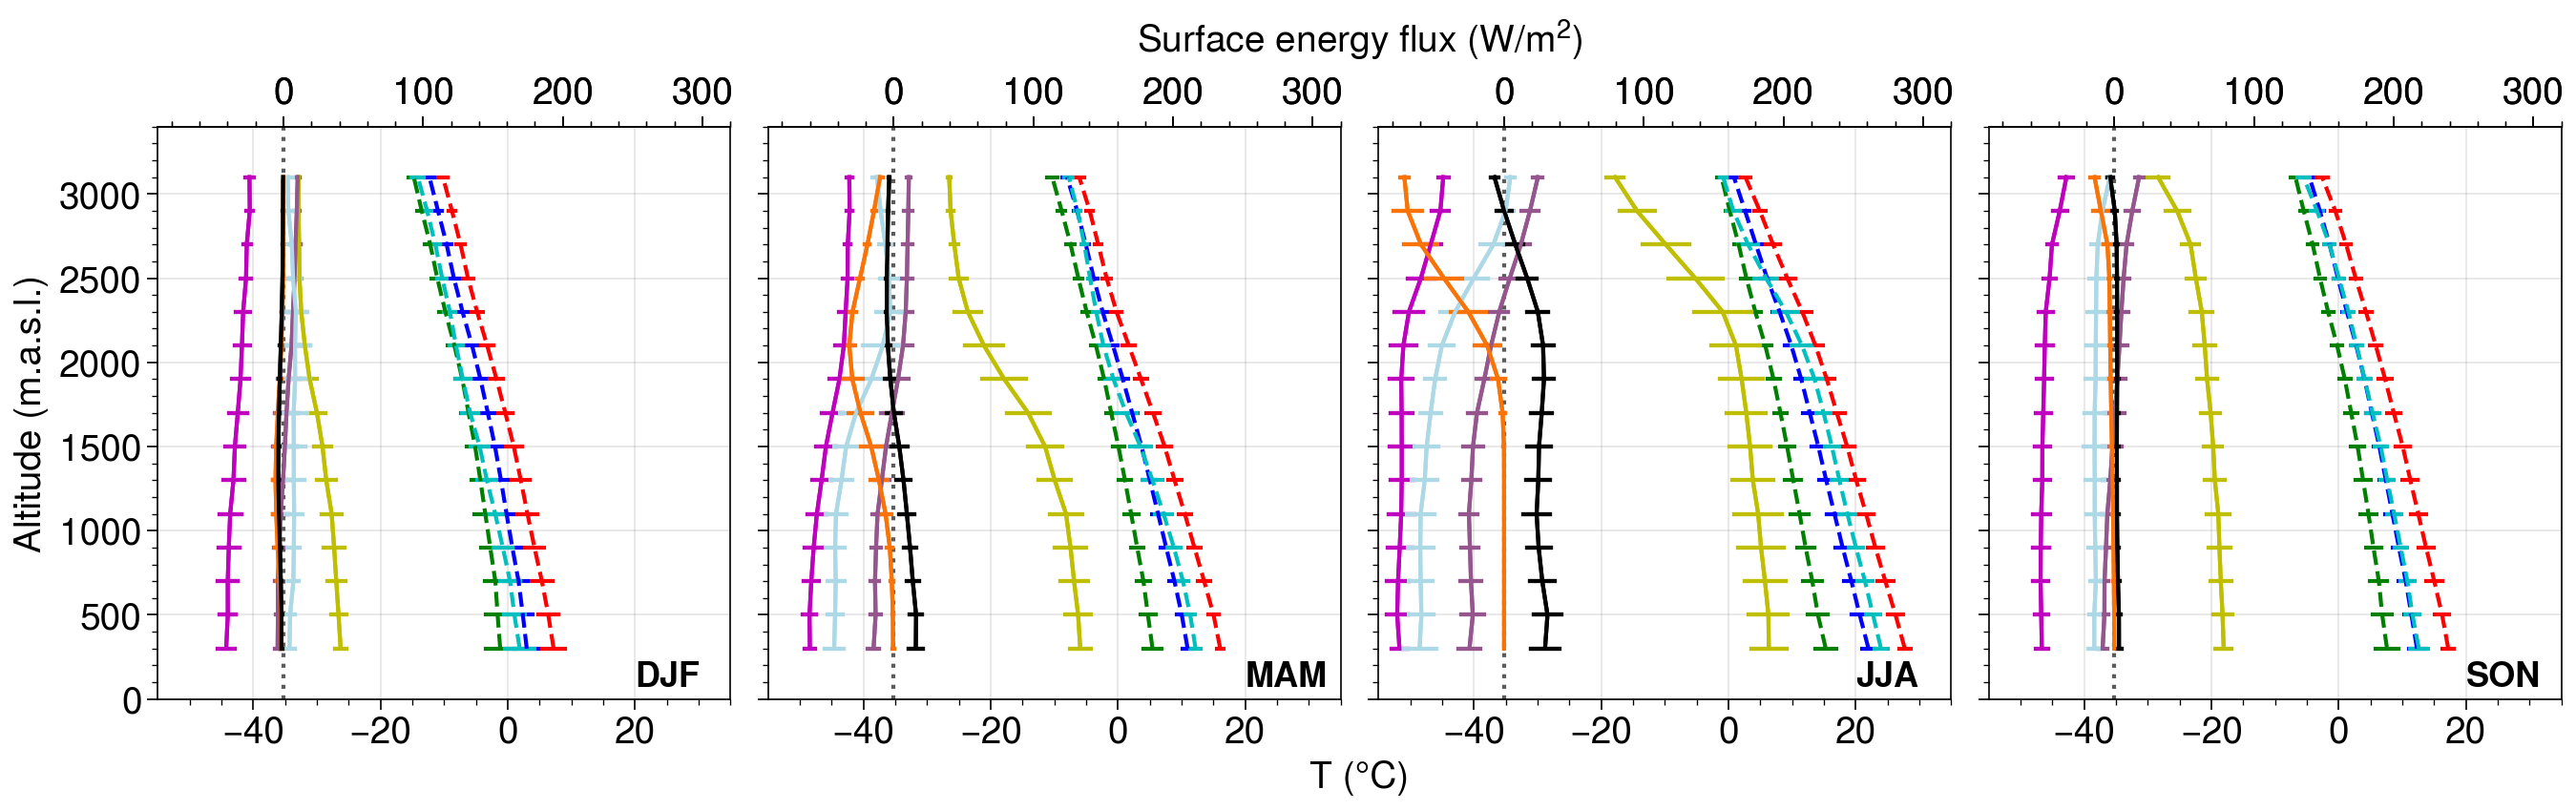

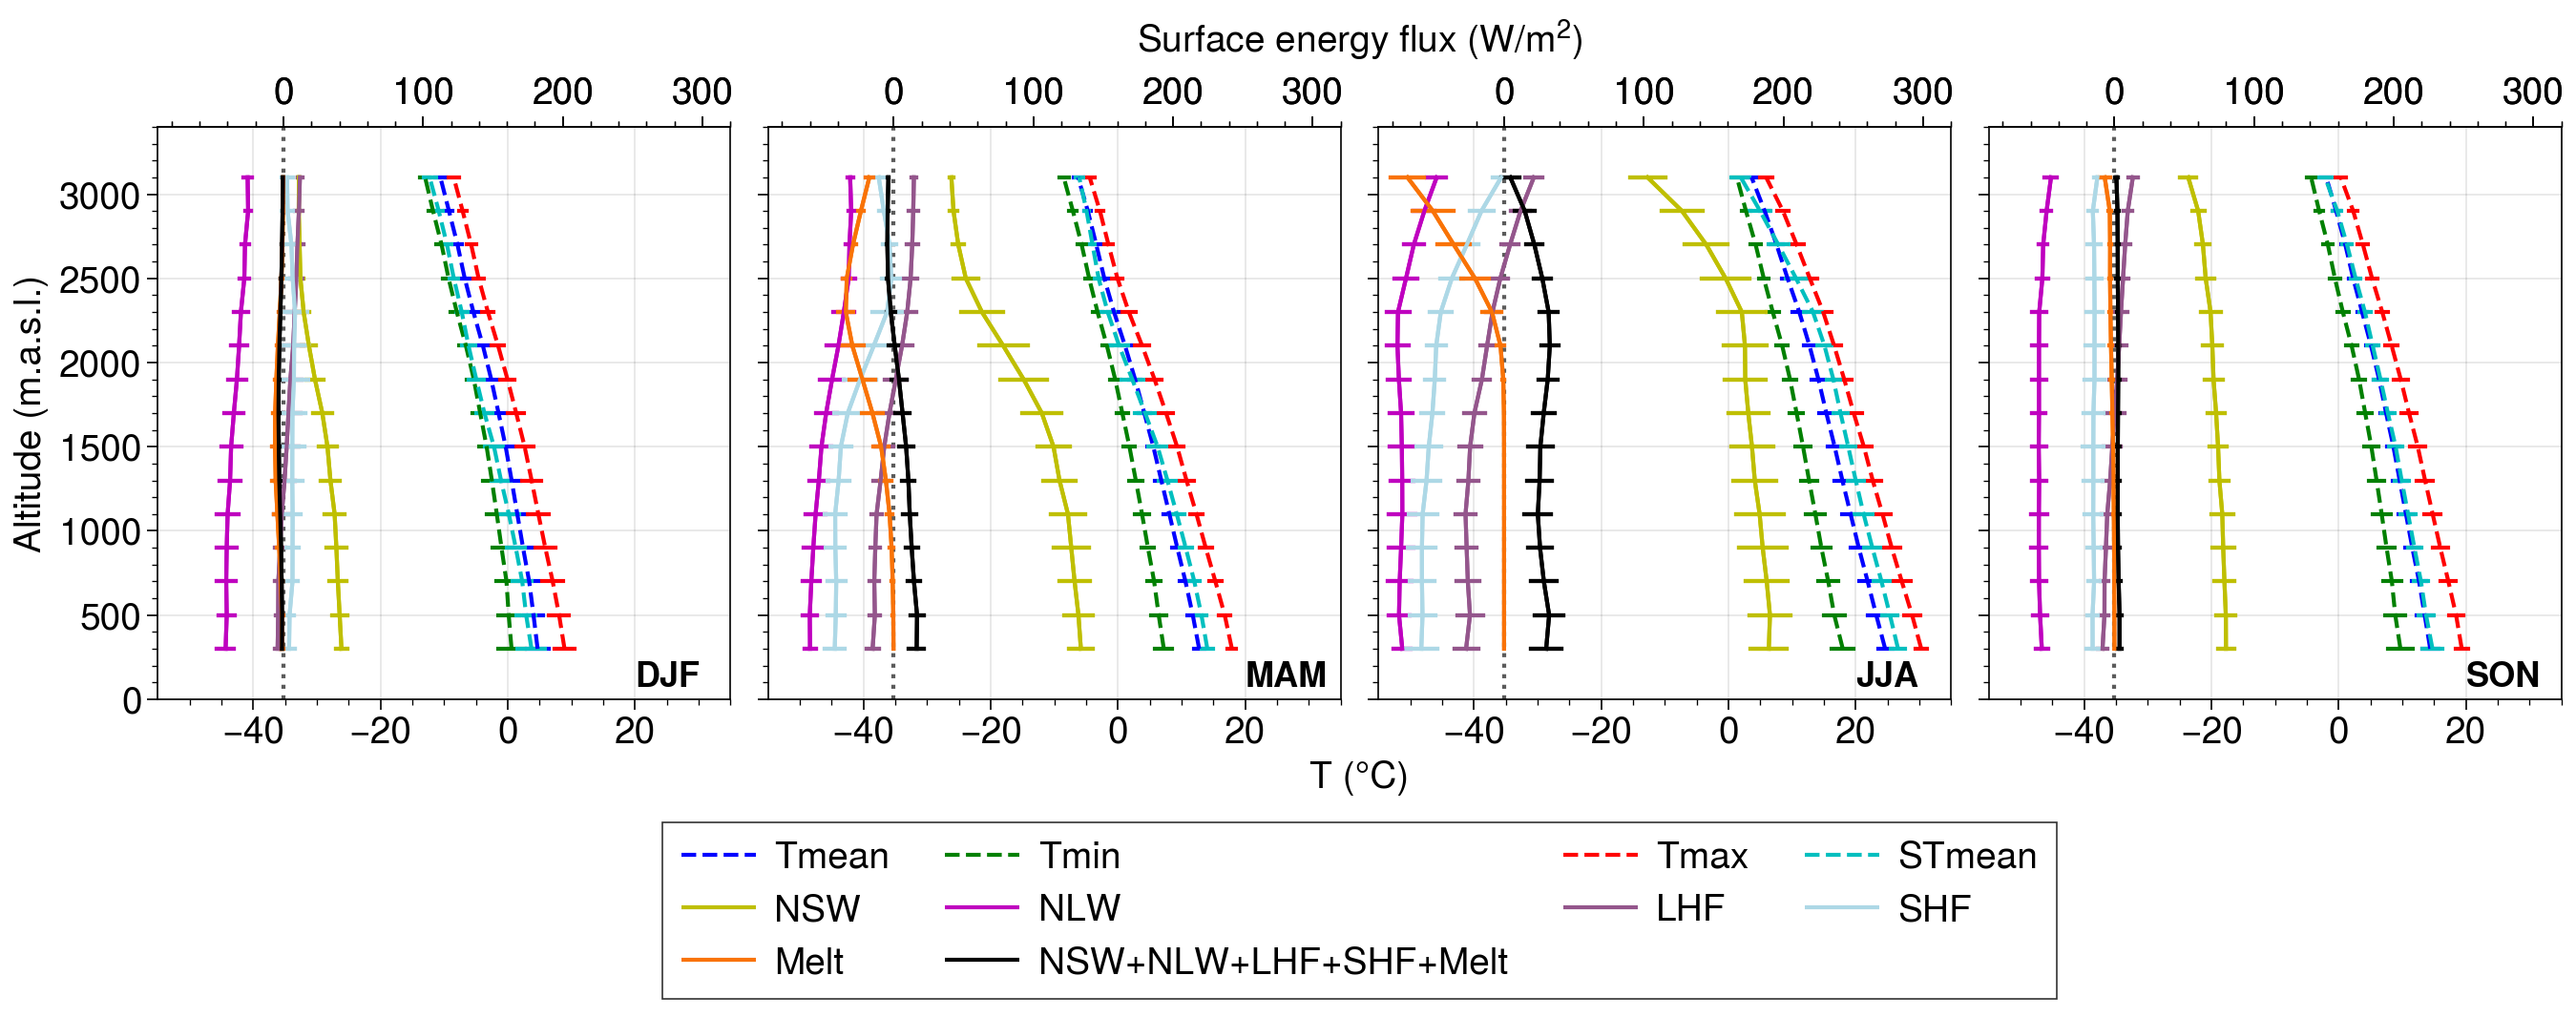

In [65]:
plot_E_balance_and_T(slopes_var=None,trend=False,first_year=0,last_year=55,showlegend=False,snowlines=False)

plot_E_balance_and_T(slopes_var=None,trend=False,first_year=55,last_year=-1,showlegend=True,snowlines=False)


In [90]:
def plot_E_balance(slopes_var=None,trend=True,year=None,first_year=None,last_year=None,showlegend=True,snowlines=False):
    pplt.rc.update(small=14, large=12)

    n_levels=len(levels)
    n_seas=4
    seasons=['DJF','MAM','JJA','SON']
    colors = ['y','m','purple','lightblue','orange','k']
    leg_labels_null = ['','','','','','','','','','']
    leg_labels_full = ['NSW','NLW','LHF','SHF','Melt','NSW+NLW+LHF+SHF+Melt']
    leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]


    with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
        f, axs = pplt.subplots(ncols=4,axwidth=3)
    # axs2 = axs.twiny()
    
    mean_slope_NSW=np.full((n_seas,n_levels),np.nan)
    mean_slope_NLW=np.full((n_seas,n_levels),np.nan)
    mean_slope_LHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_SHF=np.full((n_seas,n_levels),np.nan)
    mean_slope_MBm=np.full((n_seas,n_levels),np.nan)
    mean_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    mean_slopes = [mean_slope_NSW,mean_slope_NLW,mean_slope_LHF,mean_slope_SHF,mean_slope_MBm,
                   mean_slope_energy_balance]

    std_slope_NSW=np.full((n_seas,n_levels),np.nan)
    std_slope_NLW=np.full((n_seas,n_levels),np.nan)
    std_slope_LHF=np.full((n_seas,n_levels),np.nan)
    std_slope_SHF=np.full((n_seas,n_levels),np.nan)
    std_slope_MBm=np.full((n_seas,n_levels),np.nan)
    std_slope_energy_balance=np.full((n_seas,n_levels),np.nan)
    std_slopes = [std_slope_NSW,std_slope_NLW,std_slope_LHF,std_slope_SHF,std_slope_MBm,
                  std_slope_energy_balance]

    wp_meanseason_vars = [wp_meanseason_meanNSW,wp_meanseason_NLW,wp_meanseason_LHF,
                          wp_meanseason_SHF,wp_meanseason_meltflux,wp_meanseason_energy_balance]
    
    for i in range(n_seas): # seasons
        ax = axs[i]
        # ax2 = axs2[i]
        
        for j in range(n_levels): # levels
            for var in range(len(wp_meanseason_vars)):
                if trend:
                    slope_var = np.ma.masked_array(slopes_var[var][i], mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 10 # trends per decade so we x10
                elif first_year != None: # not a trend, but averaging over first_year:last_year
                    slope_var = np.ma.masked_array(wp_meanseason_vars[var][first_year:last_year,i].mean(axis=0), mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 1
                else: # taking one year in particular
                    slope_var = np.ma.masked_array(wp_meanseason_vars[var][year-1961,i], mask=np.invert(levels[j])).reshape(12649)
                    multiplier = 1
                
                mean_slopes[var][i,j] = multiplier*slope_var.mean()
                std_slopes[var][i,j] = multiplier*slope_var.std()

                ax.plot([multiplier*slope_var.mean()-multiplier*slope_var.std(),multiplier*slope_var.mean()+multiplier*slope_var.std()],
                             [H_levels[j],H_levels[j]],c=colors[var])


        ax.set_ylim(0,3400)
        
        # if snowlines:
            #ax.hlines(mean1_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            #ax.hlines(mean1_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            #ax.hlines(mean1_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue',linestyle='--')
            # ax.hlines(mean10_snowline_seas[0][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
            # ax.hlines(mean10_snowline_seas[1][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
            # ax.hlines(mean10_snowline_seas[2][0,first_year:last_year,i].mean(),-55,35,c='deepskyblue')
        
        ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
        ax.plot(mean_slope_NSW[i,:],H_levels,c='y',label=leg_labels[i][0])
        ax.plot(mean_slope_NLW[i,:],H_levels,c='m',label=leg_labels[i][1])
        ax.plot(mean_slope_LHF[i,:],H_levels,c='purple',label=leg_labels[i][2])
        ax.plot(mean_slope_SHF[i,:],H_levels,c='lightblue',label=leg_labels[i][3])
        ax.plot(mean_slope_MBm[i,:],H_levels,c='orange',label=leg_labels[i][4])
        ax.plot(mean_slope_energy_balance[i,:],H_levels,c='k',label=leg_labels[i][5])
        #ax2.plot(mean_slope_NSW[i,:]+mean_slope_NLW[i,:]+mean_slope_LHF[i,:]+mean_slope_SHF[i,:],H_levels,c='k',linestyle='--')

        if trend:
            ax.set_xlim(-4,7)
            ax.text(5.2, 75, seasons[i], fontsize=13,fontweight='semibold')
        else:
            ax.set_xlim(-90,220)
            ax.text(155, 75, seasons[i], fontsize=13,fontweight='semibold')

    if showlegend:
        f.legend(loc='b',prop = { "size": 14 },ncols=4)
    
    if trend:
        # xLabel = 'T trend (°C/decade)'
        # Suptitle='Surface energy flux trend (W/$m^2$/dec)'
        xLabel = 'Surface energy flux trend (W/$m^2$/dec)'
    else:
        # xLabel = 'T (°C)'
        # Suptitle='Surface energy flux (W/$m^2$)'
        xLabel = 'Surface energy flux (W/$m^2$)'

    if year != None:
        axs[0].text(x=10,y=3000,s=f'Year = {year}')
    axs.format(xlabel=xLabel,ylabel='Altitude (m.a.s.l.)')#,suptitle=Suptitle)


/tmp/ipykernel_603715/1172621398.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1172621398.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1172621398.py:2: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_603715/1172621398.py:2: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


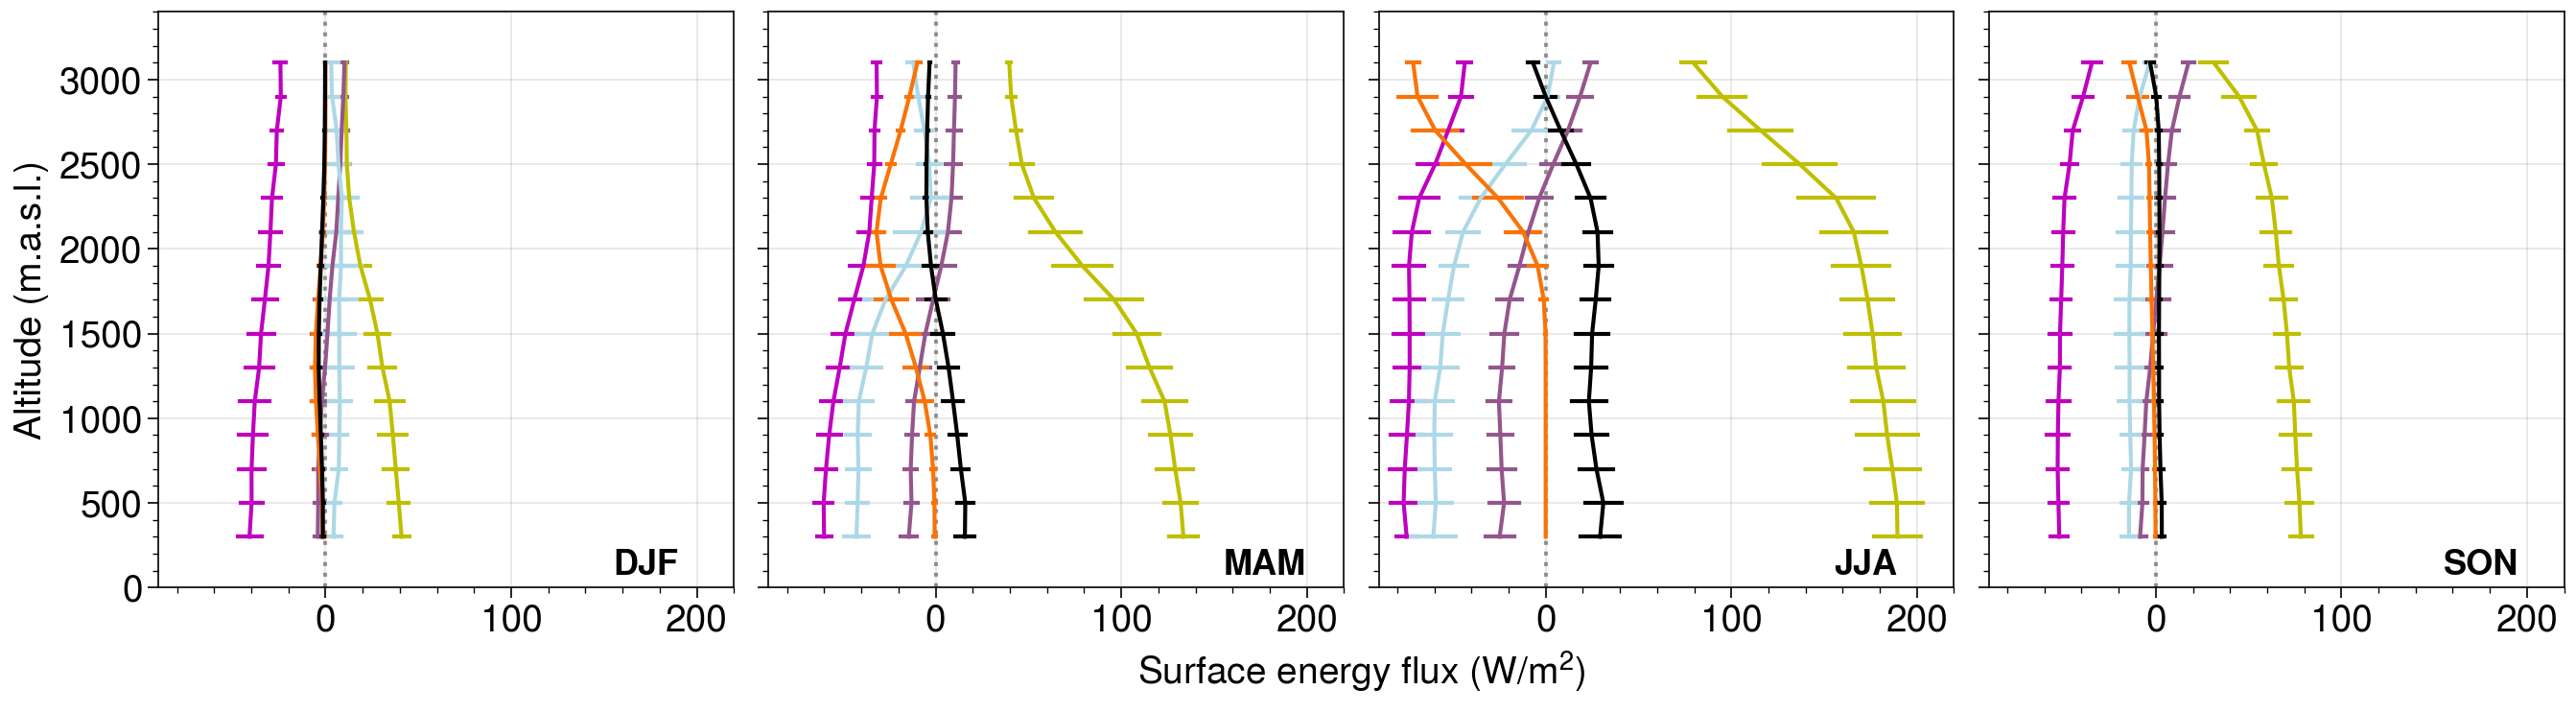

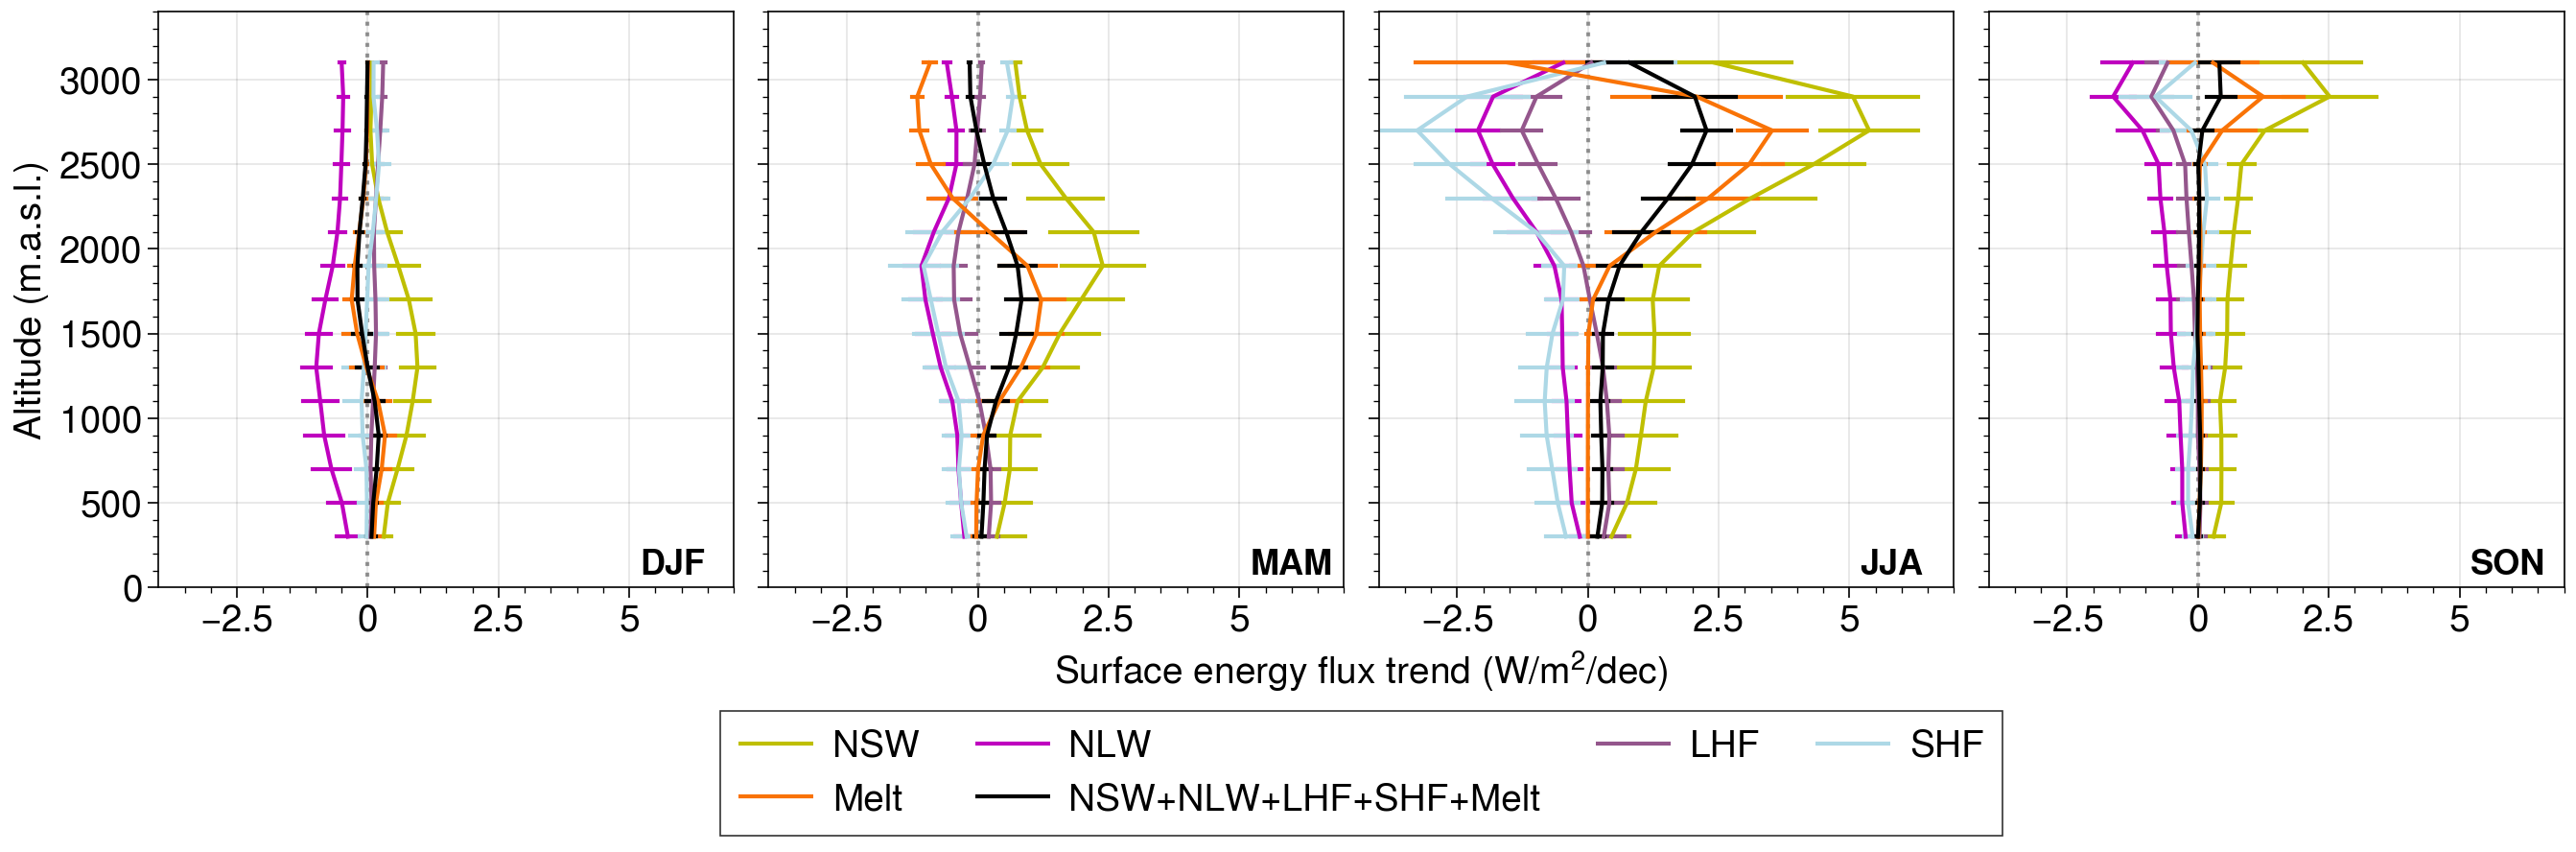

In [91]:
# Hist

plot_E_balance(slopes_var=None,trend=False,first_year=0,last_year=55,showlegend=False,snowlines=True)

slopes_variables = [slope_NSW_hist,slope_NLW_hist,slope_LHF_hist,slope_SHF_hist,slope_meltflux_hist,
                    slope_energy_balance_hist]
plot_E_balance(slopes_var=slopes_variables,trend=True,first_year=0,last_year=55,showlegend=True,snowlines=True)

In [66]:
wp_meanseason_meanT.shape

(140, 4, 91, 139)

In [67]:
seas = 1 # spring
years = np.arange(1961,2101,1)

wp_meanseason_SHF.shape

(140, 4, 91, 139)

In [68]:
mean_lvls_T=np.full((n_seas,n_levels),np.nan)
mean_lvls_Tmin=np.full((n_seas,n_levels),np.nan)
mean_lvls_Tmax=np.full((n_seas,n_levels),np.nan)
mean_lvls_NSW=np.full((n_seas,n_levels),np.nan)
mean_lvls_NLW=np.full((n_seas,n_levels),np.nan)
mean_lvls_LHF=np.full((n_seas,n_levels),np.nan)
mean_lvls_SHF=np.full((n_seas,n_levels),np.nan)
mean_lvls_energy_balance=np.full((n_seas,n_levels),np.nan)

std_lvls_T=np.full((n_seas,n_levels),np.nan)
std_lvls_Tmin=np.full((n_seas,n_levels),np.nan)
std_lvls_Tmax=np.full((n_seas,n_levels),np.nan)
std_lvls_NSW=np.full((n_seas,n_levels),np.nan)
std_lvls_NLW=np.full((n_seas,n_levels),np.nan)
std_lvls_LHF=np.full((n_seas,n_levels),np.nan)
std_lvls_SHF=np.full((n_seas,n_levels),np.nan)
std_lvls_energy_balance=np.full((n_seas,n_levels),np.nan)

NameError: name 'n_seas' is not defined

In [45]:
alps700_NSW = np.full(140,np.nan)
alps2100_NSW = np.full(140,np.nan)

alps700_NLW = np.full(140,np.nan)
alps2100_NLW = np.full(140,np.nan)

alps700_SHF = np.full(140,np.nan)
alps2100_SHF = np.full(140,np.nan)

alps700_LHF = np.full(140,np.nan)
alps2100_LHF = np.full(140,np.nan)

for year in range(140):
    wp_meanseason_SHF_alps700 = np.ma.masked_array(wp_meanseason_SHF[year,seas], mask=np.invert(levels[2])).reshape(12649)
    alps700_SHF[year] = wp_meanseason_SHF_alps700.mean()
    wp_meanseason_SHF_alps2100 = np.ma.masked_array(wp_meanseason_SHF[year,seas], mask=np.invert(levels[9])).reshape(12649)
    alps2100_SHF[year] = wp_meanseason_SHF_alps2100.mean()

    wp_meanseason_NSW_alps700 = np.ma.masked_array(wp_meanseason_meanNSW[year,seas], mask=np.invert(levels[2])).reshape(12649)
    alps700_NSW[year] = wp_meanseason_NSW_alps700.mean()
    wp_meanseason_NSW_alps2100 = np.ma.masked_array(wp_meanseason_meanNSW[year,seas], mask=np.invert(levels[9])).reshape(12649)
    alps2100_NSW[year] = wp_meanseason_NSW_alps2100.mean()

    wp_meanseason_NLW_alps700 = np.ma.masked_array(wp_meanseason_NLW[year,seas], mask=np.invert(levels[2])).reshape(12649)
    alps700_NLW[year] = wp_meanseason_NLW_alps700.mean()
    wp_meanseason_NLW_alps2100 = np.ma.masked_array(wp_meanseason_NLW[year,seas], mask=np.invert(levels[9])).reshape(12649)
    alps2100_NLW[year] = wp_meanseason_NLW_alps2100.mean()

    wp_meanseason_LHF_alps700 = np.ma.masked_array(wp_meanseason_LHF[year,seas], mask=np.invert(levels[2])).reshape(12649)
    alps700_LHF[year] = wp_meanseason_LHF_alps700.mean()
    wp_meanseason_LHF_alps2100 = np.ma.masked_array(wp_meanseason_LHF[year,seas], mask=np.invert(levels[9])).reshape(12649)
    alps2100_LHF[year] = wp_meanseason_LHF_alps2100.mean()

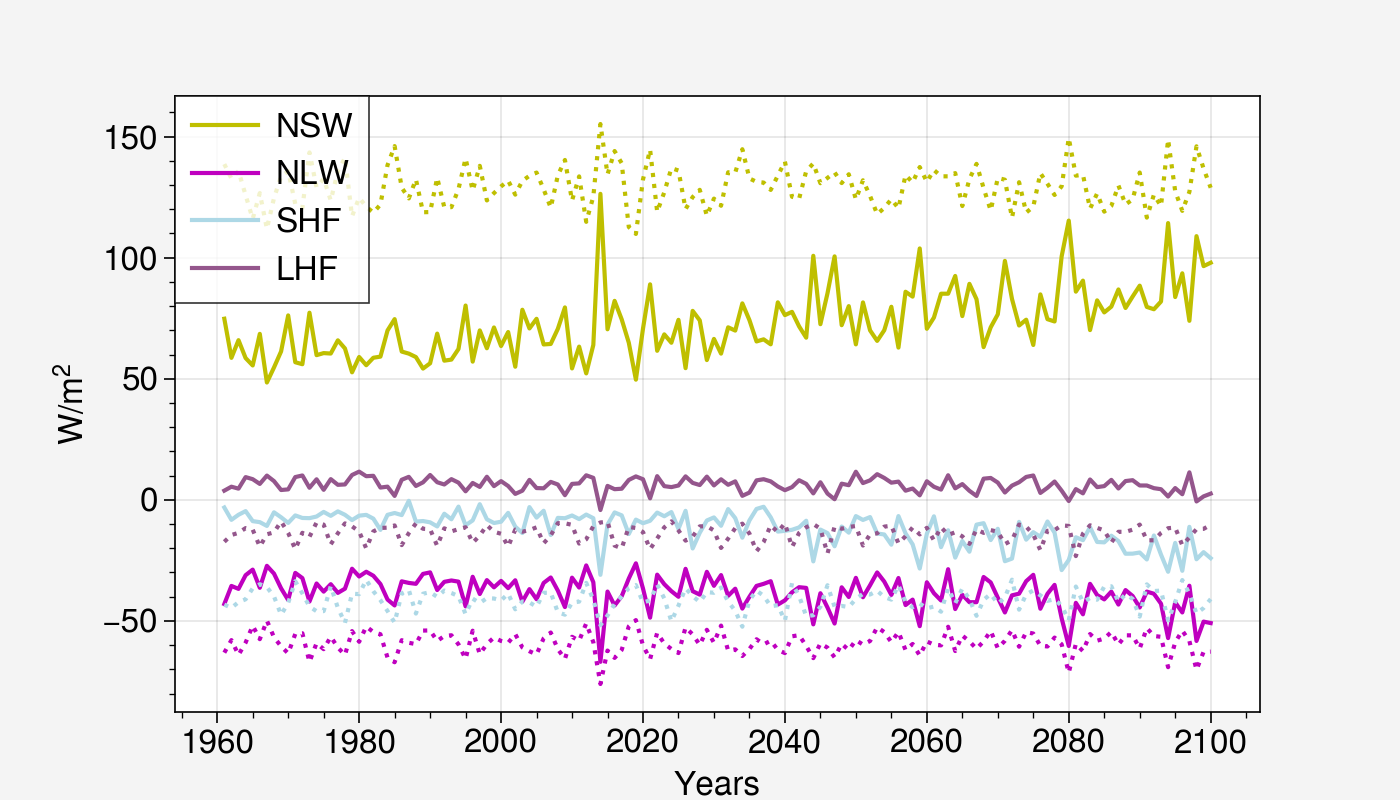

In [46]:
f,ax = plt.subplots(figsize=(7, 4))

ax.plot(years,alps700_NSW,c='y',linestyle=':')
ax.plot(years,alps2100_NSW,c='y',label='NSW')

ax.plot(years,alps700_NLW,c='m',linestyle=':')
ax.plot(years,alps2100_NLW,c='m',label='NLW')

ax.plot(years,alps700_SHF,c='lightblue',linestyle=':')
ax.plot(years,alps2100_SHF,c='lightblue',label='SHF')

ax.plot(years,alps700_LHF,c='purple',linestyle=':')
ax.plot(years,alps2100_LHF,c='purple',label='LHF')

ax.set_xlabel('Years')
ax.set_ylabel('W/$m^2$')
ax.legend()